In [2]:

# ── CELDA 1: IMPORTS Y CONEXIÓN 
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec
import gspread
from google.oauth2.service_account import Credentials

# Estilo global
plt.rcParams.update({
    "figure.dpi": 130,
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
})

COLORES_METODO = {
    "LinearRegression":        "#2E86AB",
    "Ridge":                   "#A23B72",
    "RandomForestRegressor":   "#F18F01",
    "GradientBoostingRegressor": "#4CAF50",
}

COLORES_ARCHIVO = {
    "df_semanal.csv":  "#264653",
    "df_semanal_1.csv":"#2A9D8F",
    "df_semanal_2.csv":"#E9C46A",
    "df_semanal_3.csv":"#F4A261",
    "df_semanal_4.csv":"#E76F51",
}

LAGS_LABEL = {
    "df_semanal.csv":  "0 lags",
    "df_semanal_1.csv":"1 lag",
    "df_semanal_2.csv":"2 lags",
    "df_semanal_3.csv":"3 lags",
    "df_semanal_4.csv":"4 lags",
}


In [3]:

# LEER GOOGLE SHEETS 
SCOPES = [
    "https://www.googleapis.com/auth/spreadsheets",
    "https://www.googleapis.com/auth/drive",
]
SERVICE_ACCOUNT_FILE = "credenciales_google.json"
SHEET_URL = "https://docs.google.com/spreadsheets/d/17T0L6gza7vzD1vFh6OG2j3qOmlKCDRtFFu5HNma1Agk/edit?gid=836870544#gid=836870544"

def conectar_y_leer():
    creds = Credentials.from_service_account_file(SERVICE_ACCOUNT_FILE, scopes=SCOPES)
    client = gspread.authorize(creds)
    ws = client.open_by_url(SHEET_URL).get_worksheet(0)
    records = ws.get_all_records()
    df = pd.DataFrame(records)
    return df

df_raw = conectar_y_leer()
print(f"Filas leídas: {len(df_raw)}")
print(df_raw.columns.tolist())



Filas leídas: 1160
['Archivo', 'Método', 'Target', 'FechaIni', 'FechaFin', 'RMSE', 'RMSE_baseline', 'RMSE_zeros', 'MAE', 'MAE_baseline', 'MAE_zeros', 'Estado', 'Alpha', 'n_estimators', 'max_depth', 'min_samples_leaf', 'max_features', 'learning_rate', 'subsample', 'FechaPredIni', 'FechaPredFin', 'FechaTrainIni', 'FechaTrainFin']


In [ ]:
# LIMPIEZA Y PREPARACIÓN ─
def limpiar(df):
    df = df.copy()

    # Solo filas DONE
    df = df[df["Estado"].str.upper() == "DONE"].copy()

    # Columnas numéricas — reemplazar comas por puntos si vienen así
    num_cols = ["RMSE", "RMSE_baseline", "RMSE_zeros",
                "MAE",  "MAE_baseline",  "MAE_zeros"]
    for c in num_cols:
        df[c] = df[c].astype(str).str.replace(",", ".").str.strip()
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # ETF limpio
    df["ETF"] = df["Target"].str.replace("target_", "", regex=False)

    # Número de lags
    df["Lags"] = df["Archivo"].map(LAGS_LABEL).fillna("?")

    # Mejora relativa vs baseline naive (%)
    df["Mejora_vs_baseline"] = (
        (df["RMSE_baseline"] - df["RMSE"]) / df["RMSE_baseline"] * 100
    ).round(2)

    # Mejora relativa vs zeros (%)
    df["Mejora_vs_zeros"] = (
        (df["RMSE_zeros"] - df["RMSE"]) / df["RMSE_zeros"] * 100
    ).round(2)

    # Bate al baseline naive?
    df["Bate_baseline"] = df["RMSE"] < df["RMSE_baseline"]
    # Bate al zeros?
    df["Bate_zeros"] = df["RMSE"] < df["RMSE_zeros"]

    return df

df = limpiar(df_raw)
print(f"\nExperimentos DONE: {len(df)}")
print(f"Métodos: {df['Método'].unique()}")
print(f"Archivos: {df['Archivo'].unique()}")




Experimentos DONE: 1160
Métodos: <ArrowStringArray>
[         'LinearRegression',                     'Ridge',
     'RandomForestRegressor', 'GradientBoostingRegressor']
Length: 4, dtype: str
Archivos: <ArrowStringArray>
[  'df_semanal.csv', 'df_semanal_1.csv', 'df_semanal_2.csv',
 'df_semanal_3.csv', 'df_semanal_4.csv']
Length: 5, dtype: str


In [5]:

# TABLAS RESUMEN
# TABLA RESUMEN GENERAL por Método y Archivo
print("\n" + "="*70)
print("TABLA 1 — RMSE medio por Método y Archivo (número de lags)")
print("="*70)

tabla1 = df.groupby(["Archivo","Método"])[["RMSE","RMSE_baseline","RMSE_zeros"]].mean().round(5)
tabla1["Mejora_vs_baseline(%)"] = (
    (tabla1["RMSE_baseline"] - tabla1["RMSE"]) / tabla1["RMSE_baseline"] * 100
).round(2)
tabla1["Mejora_vs_zeros(%)"] = (
    (tabla1["RMSE_zeros"] - tabla1["RMSE"]) / tabla1["RMSE_zeros"] * 100
).round(2)
print(tabla1.to_string())



TABLA 1 — RMSE medio por Método y Archivo (número de lags)
                                                  RMSE  RMSE_baseline  RMSE_zeros  Mejora_vs_baseline(%)  Mejora_vs_zeros(%)
Archivo          Método                                                                                                     
df_semanal.csv   GradientBoostingRegressor   481.98276      692.75862   441.67241                  30.43               -9.13
                 LinearRegression            707.27586      692.75862   441.67241                  -2.10              -60.14
                 RandomForestRegressor       451.37931      692.75862   441.67241                  34.84               -2.20
                 Ridge                       456.87931      692.75862   441.67241                  34.05               -3.44
df_semanal_1.csv GradientBoostingRegressor   441.77586      692.75862   441.67241                  36.23               -0.02
                 LinearRegression           1301.46552      692.7

In [6]:

#  TABLA RANKING de métodos 
print("\n" + "="*70)
print("TABLA 2 — Ranking de métodos por RMSE medio global")
print("="*70)

tabla2 = df.groupby("Método")[["RMSE","RMSE_baseline","RMSE_zeros",
                                "Mejora_vs_baseline","Mejora_vs_zeros"]].mean().round(5)
tabla2 = tabla2.sort_values("RMSE")
print(tabla2.to_string())




TABLA 2 — Ranking de métodos por RMSE medio global
                                 RMSE  RMSE_baseline  RMSE_zeros  Mejora_vs_baseline  Mejora_vs_zeros
Método                                                                                               
GradientBoostingRegressor   446.47586      692.75862   441.67241            16.68703        -93.60366
Ridge                       449.62069      692.75862   441.67241            22.78455        -98.35155
RandomForestRegressor       454.13448      692.75862   441.67241            18.03403        -94.12666
LinearRegression           1477.96207      692.75862   441.67241          -184.98390       -550.25600


In [7]:
# TABLA por ETF — mejor modelo 
print("\n" + "="*70)
print("TABLA 3 — Mejor modelo por ETF (menor RMSE global)")
print("="*70)

# Para cada ETF, qué combinación Archivo+Método da menor RMSE
idx_min = df.groupby("ETF")["RMSE"].idxmin()
tabla3 = df.loc[idx_min, ["ETF","Archivo","Método","RMSE",
                           "RMSE_baseline","RMSE_zeros",
                           "Mejora_vs_baseline","Mejora_vs_zeros"]].set_index("ETF")
print(tabla3.to_string())




TABLA 3 — Mejor modelo por ETF (menor RMSE global)
               Archivo                     Método  RMSE  RMSE_baseline  RMSE_zeros  Mejora_vs_baseline  Mejora_vs_zeros
ETF                                                                                                                    
AGG     df_semanal.csv                      Ridge   154            226         153               31.86            -0.65
BND   df_semanal_1.csv           LinearRegression    47            221         151               78.73            68.87
DBC     df_semanal.csv  GradientBoostingRegressor   589            807         614               27.01             4.07
DIA     df_semanal.csv                      Ridge    44            683         447               93.56            90.16
DVY   df_semanal_3.csv      RandomForestRegressor     4            601         402               99.33            99.00
EEM     df_semanal.csv  GradientBoostingRegressor   474            676         476               29.88      

In [8]:
# TABLA — % de ETFs que baten cada benchmark 
print("\n" + "="*70)
print("TABLA 4 — % de ETFs que baten cada benchmark por Método")
print("="*70)

tabla4 = df.groupby("Método").agg(
    Pct_bate_baseline=("Bate_baseline", lambda x: round(x.mean()*100, 1)),
    Pct_bate_zeros=("Bate_zeros",    lambda x: round(x.mean()*100, 1)),
    N_experimentos=("RMSE", "count")
).sort_values("Pct_bate_baseline", ascending=False)
print(tabla4.to_string())



TABLA 4 — % de ETFs que baten cada benchmark por Método
                           Pct_bate_baseline  Pct_bate_zeros  N_experimentos
Método                                                                      
Ridge                                   97.6            53.1             290
RandomForestRegressor                   96.9            55.9             290
GradientBoostingRegressor               96.6            44.8             290
LinearRegression                        13.8             9.3             290


In [9]:

# TABLA — efecto de los lags 
print("\n" + "="*70)
print("TABLA 5 — RMSE medio por número de lags y Método")
print("="*70)

tabla5 = df.pivot_table(
    index="Lags", columns="Método", values="RMSE",
    aggfunc="mean"
).round(5)
orden_lags = ["0 lags","1 lag","2 lags","3 lags","4 lags"]
tabla5 = tabla5.reindex([l for l in orden_lags if l in tabla5.index])
print(tabla5.to_string())



TABLA 5 — RMSE medio por número de lags y Método
Método  GradientBoostingRegressor  LinearRegression  RandomForestRegressor      Ridge
Lags                                                                                 
0 lags                  481.98276         707.27586              451.37931  456.87931
1 lag                   441.77586        1301.46552              458.98276  438.63793
2 lags                  436.62069        2521.22414              461.13793  431.94828
3 lags                  421.89655        1576.84483              441.22414  459.41379
4 lags                  450.10345        1283.00000              457.94828  461.22414


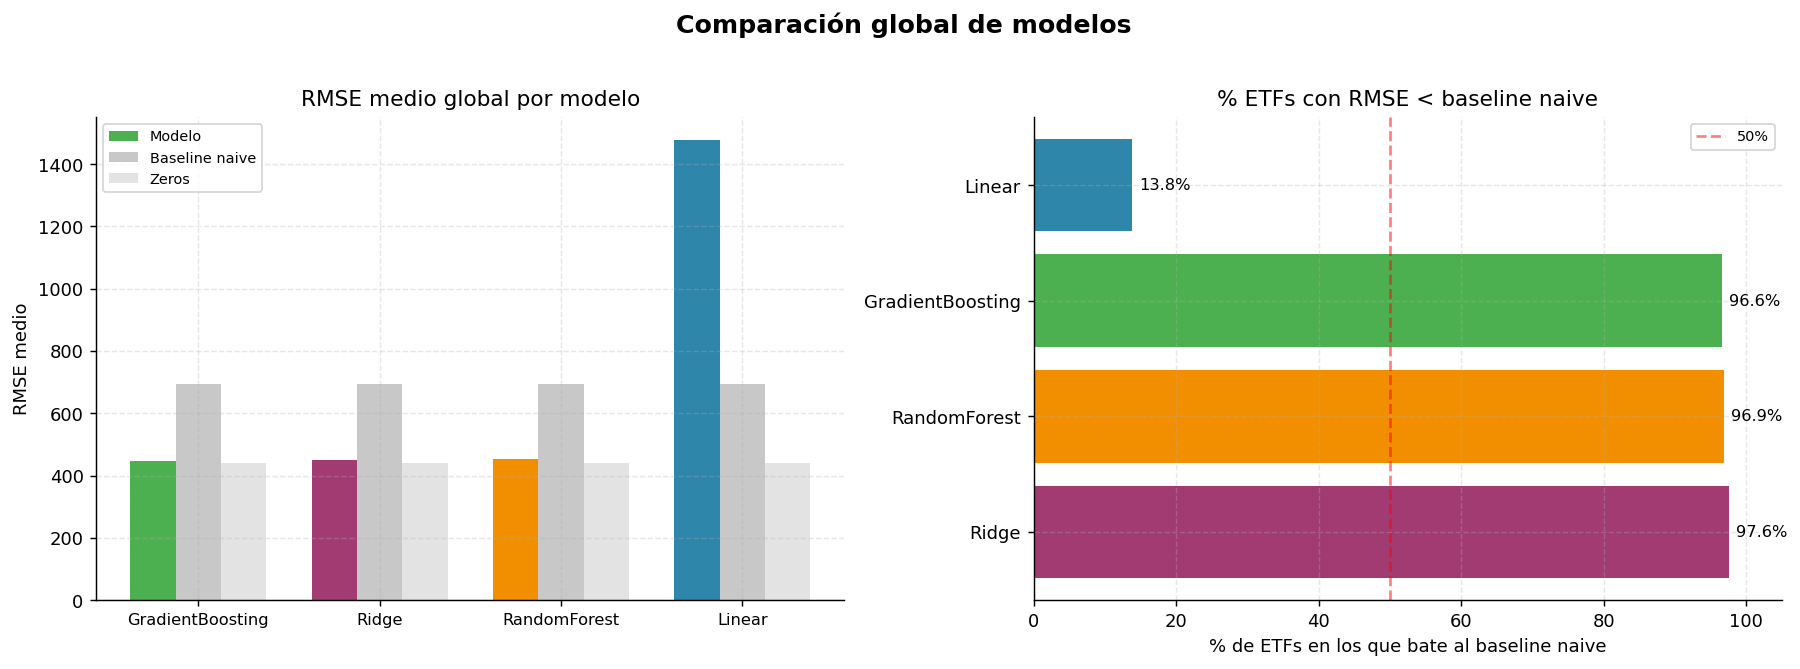

In [10]:


# GRÁFICAS GENERALES
#   RMSE medio por Método (barras)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Comparación global de modelos", fontsize=14, fontweight="bold", y=1.02)

# Subplot A: RMSE medio
medias = df.groupby("Método")[["RMSE","RMSE_baseline","RMSE_zeros"]].mean()
medias = medias.sort_values("RMSE")
x = np.arange(len(medias))
w = 0.25
ax = axes[0]
ax.bar(x - w, medias["RMSE"],          w, label="Modelo",   color=[COLORES_METODO.get(m,"#888") for m in medias.index])
ax.bar(x,     medias["RMSE_baseline"], w, label="Baseline naive", color="#BBBBBB", alpha=0.8)
ax.bar(x + w, medias["RMSE_zeros"],    w, label="Zeros",     color="#DDDDDD", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([m.replace("Regressor","").replace("Regression","") for m in medias.index], fontsize=9)
ax.set_ylabel("RMSE medio")
ax.set_title("RMSE medio global por modelo")
ax.legend(fontsize=8)

# Subplot B: % que baten baseline
ax2 = axes[1]
pct = df.groupby("Método")["Bate_baseline"].mean() * 100
pct = pct.sort_values(ascending=False)
bars = ax2.barh(
    [m.replace("Regressor","").replace("Regression","") for m in pct.index],
    pct.values,
    color=[COLORES_METODO.get(m,"#888") for m in pct.index]
)
ax2.axvline(50, color="red", linestyle="--", alpha=0.5, label="50%")
ax2.set_xlabel("% de ETFs en los que bate al baseline naive")
ax2.set_title("% ETFs con RMSE < baseline naive")
ax2.set_xlim(0, 105)
for bar, v in zip(bars, pct.values):
    ax2.text(v + 1, bar.get_y() + bar.get_height()/2, f"{v:.1f}%", va="center", fontsize=9)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig("G01_comparacion_global_modelos.png", bbox_inches="tight")
plt.show()


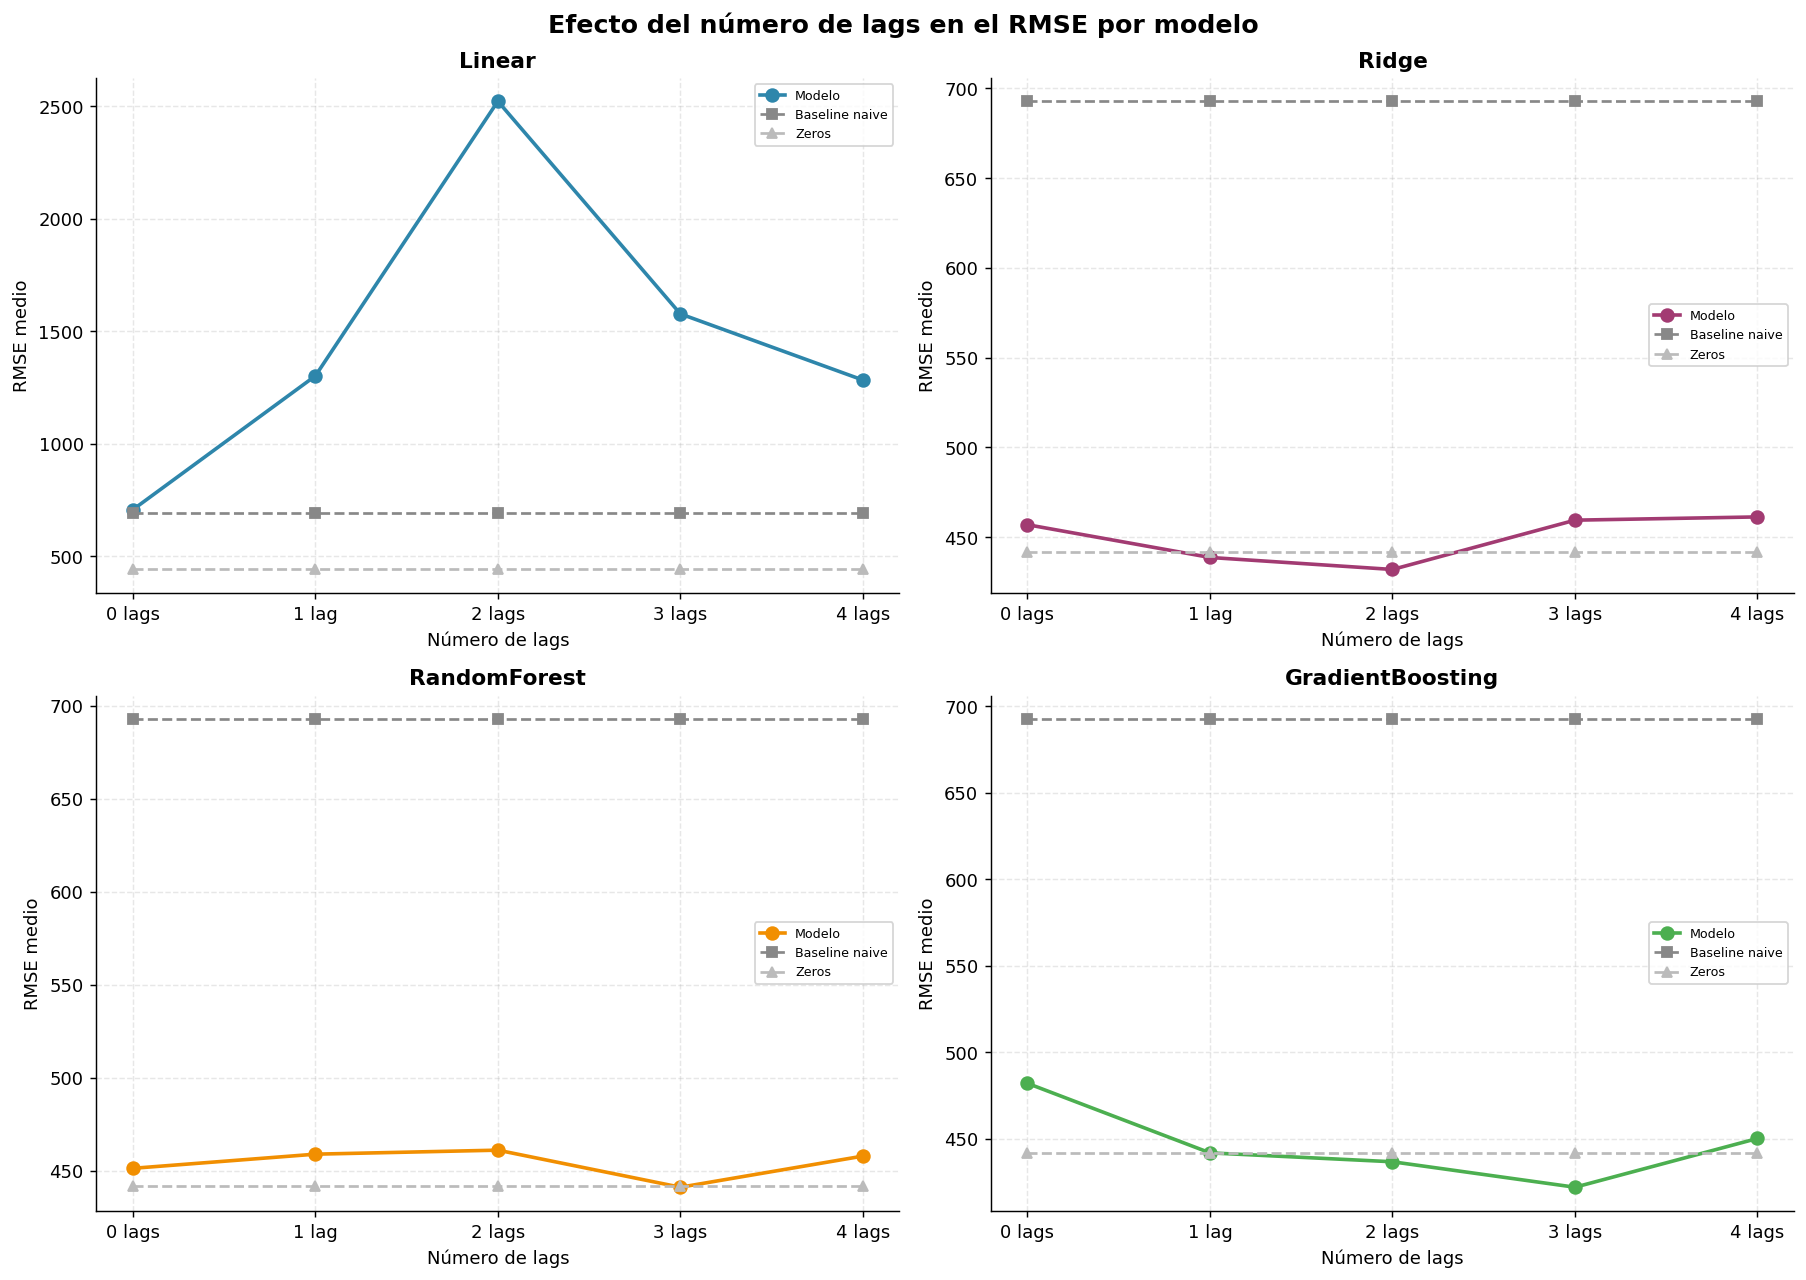

In [11]:

#  Efecto de los lags por Método 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Efecto del número de lags en el RMSE por modelo", fontsize=14, fontweight="bold")

metodos_lista = df["Método"].unique()
archivos_orden = ["df_semanal.csv","df_semanal_1.csv","df_semanal_2.csv",
                  "df_semanal_3.csv","df_semanal_4.csv"]
lags_labels = [LAGS_LABEL[a] for a in archivos_orden if a in LAGS_LABEL]

for ax, metodo in zip(axes.flatten(), metodos_lista):
    sub = df[df["Método"] == metodo]
    medias_arch = sub.groupby("Archivo")[["RMSE","RMSE_baseline","RMSE_zeros"]].mean()
    medias_arch = medias_arch.reindex([a for a in archivos_orden if a in medias_arch.index])
    x_labels = [LAGS_LABEL.get(a, a) for a in medias_arch.index]
    
    ax.plot(x_labels, medias_arch["RMSE"],          "o-", color=COLORES_METODO.get(metodo,"#333"),
            lw=2, ms=7, label="Modelo")
    ax.plot(x_labels, medias_arch["RMSE_baseline"], "s--", color="#888", lw=1.5, ms=5, label="Baseline naive")
    ax.plot(x_labels, medias_arch["RMSE_zeros"],    "^--", color="#BBB", lw=1.5, ms=5, label="Zeros")
    ax.set_title(metodo.replace("Regressor","").replace("Regression",""), fontweight="bold")
    ax.set_xlabel("Número de lags")
    ax.set_ylabel("RMSE medio")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("G02_efecto_lags_por_modelo.png", bbox_inches="tight")
plt.show()


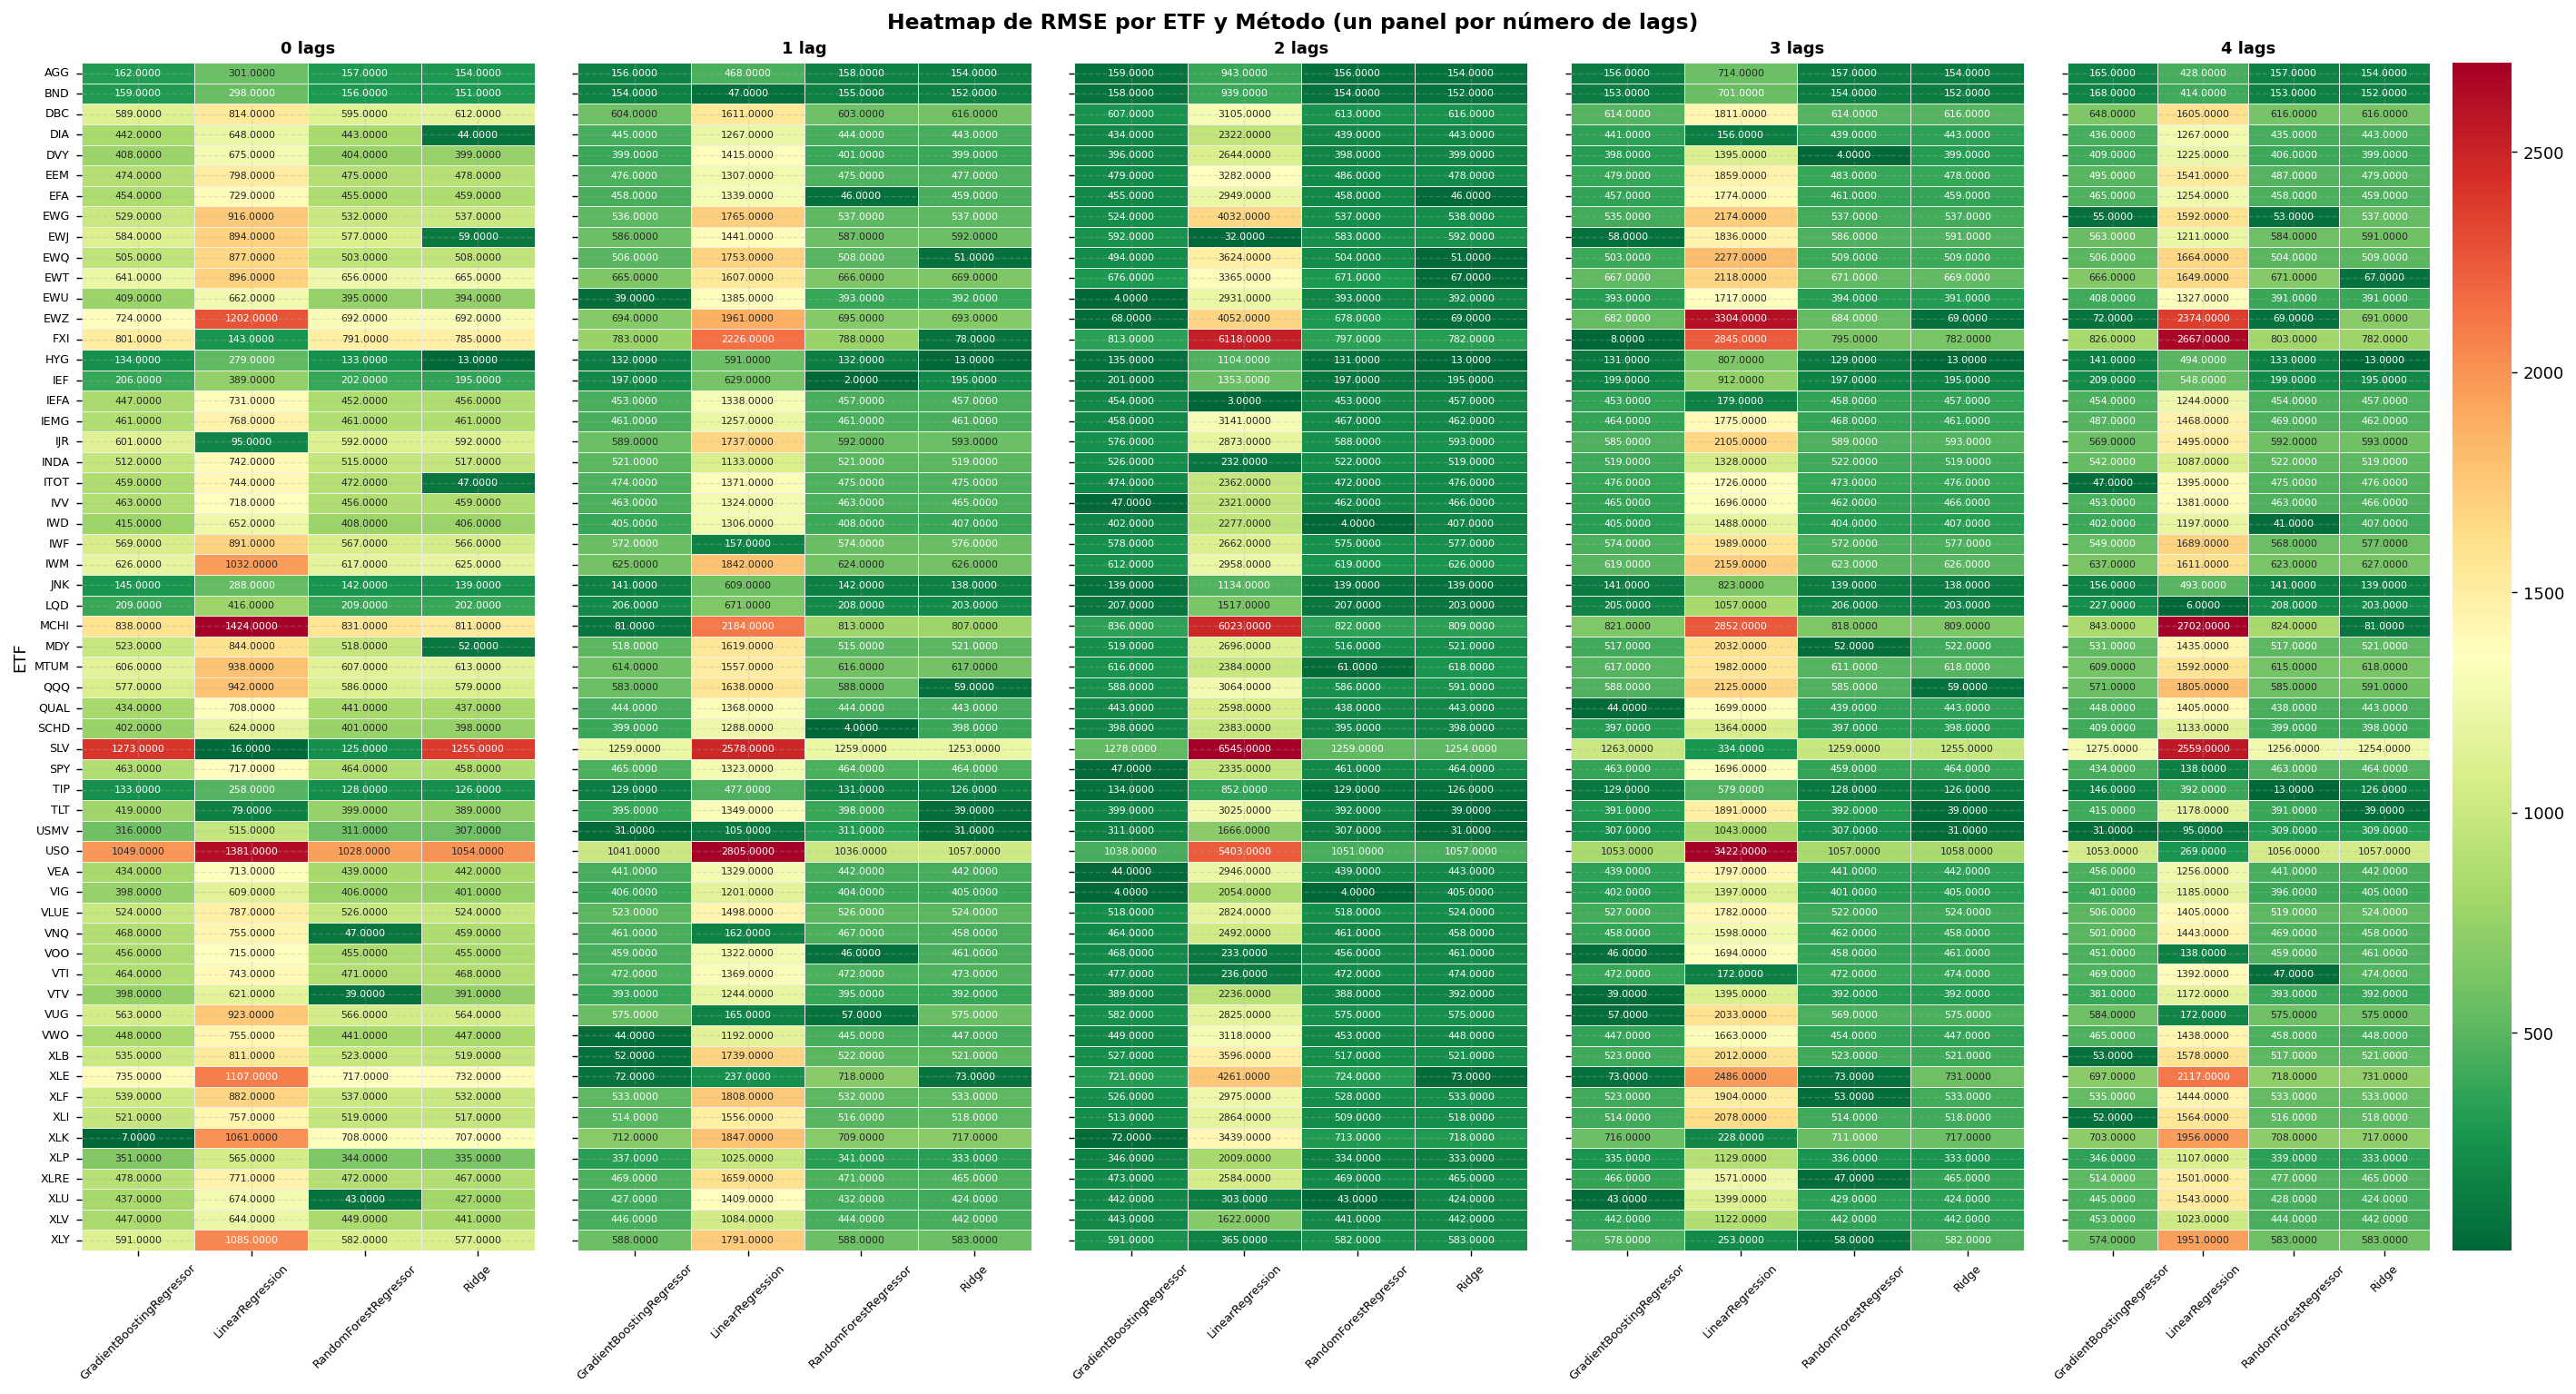

In [12]:

#  Heatmap RMSE por ETF y Método
fig, axes = plt.subplots(1, len(archivos_orden), figsize=(22, 12), sharey=True)
fig.suptitle("Heatmap de RMSE por ETF y Método (un panel por número de lags)",
             fontsize=13, fontweight="bold")

for ax, archivo in zip(axes, archivos_orden):
    sub = df[df["Archivo"] == archivo]
    pivot = sub.pivot_table(index="ETF", columns="Método", values="RMSE", aggfunc="mean")
    sns.heatmap(
        pivot, ax=ax, cmap="RdYlGn_r", annot=True, fmt=".4f",
        annot_kws={"size": 6}, linewidths=0.3, linecolor="#eee",
        cbar=ax == axes[-1]
    )
    ax.set_title(LAGS_LABEL.get(archivo, archivo), fontsize=10, fontweight="bold")
    ax.set_xlabel("")
    if ax != axes[0]:
        ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.savefig("G03_heatmap_rmse_etf_metodo.png", bbox_inches="tight")
plt.show()


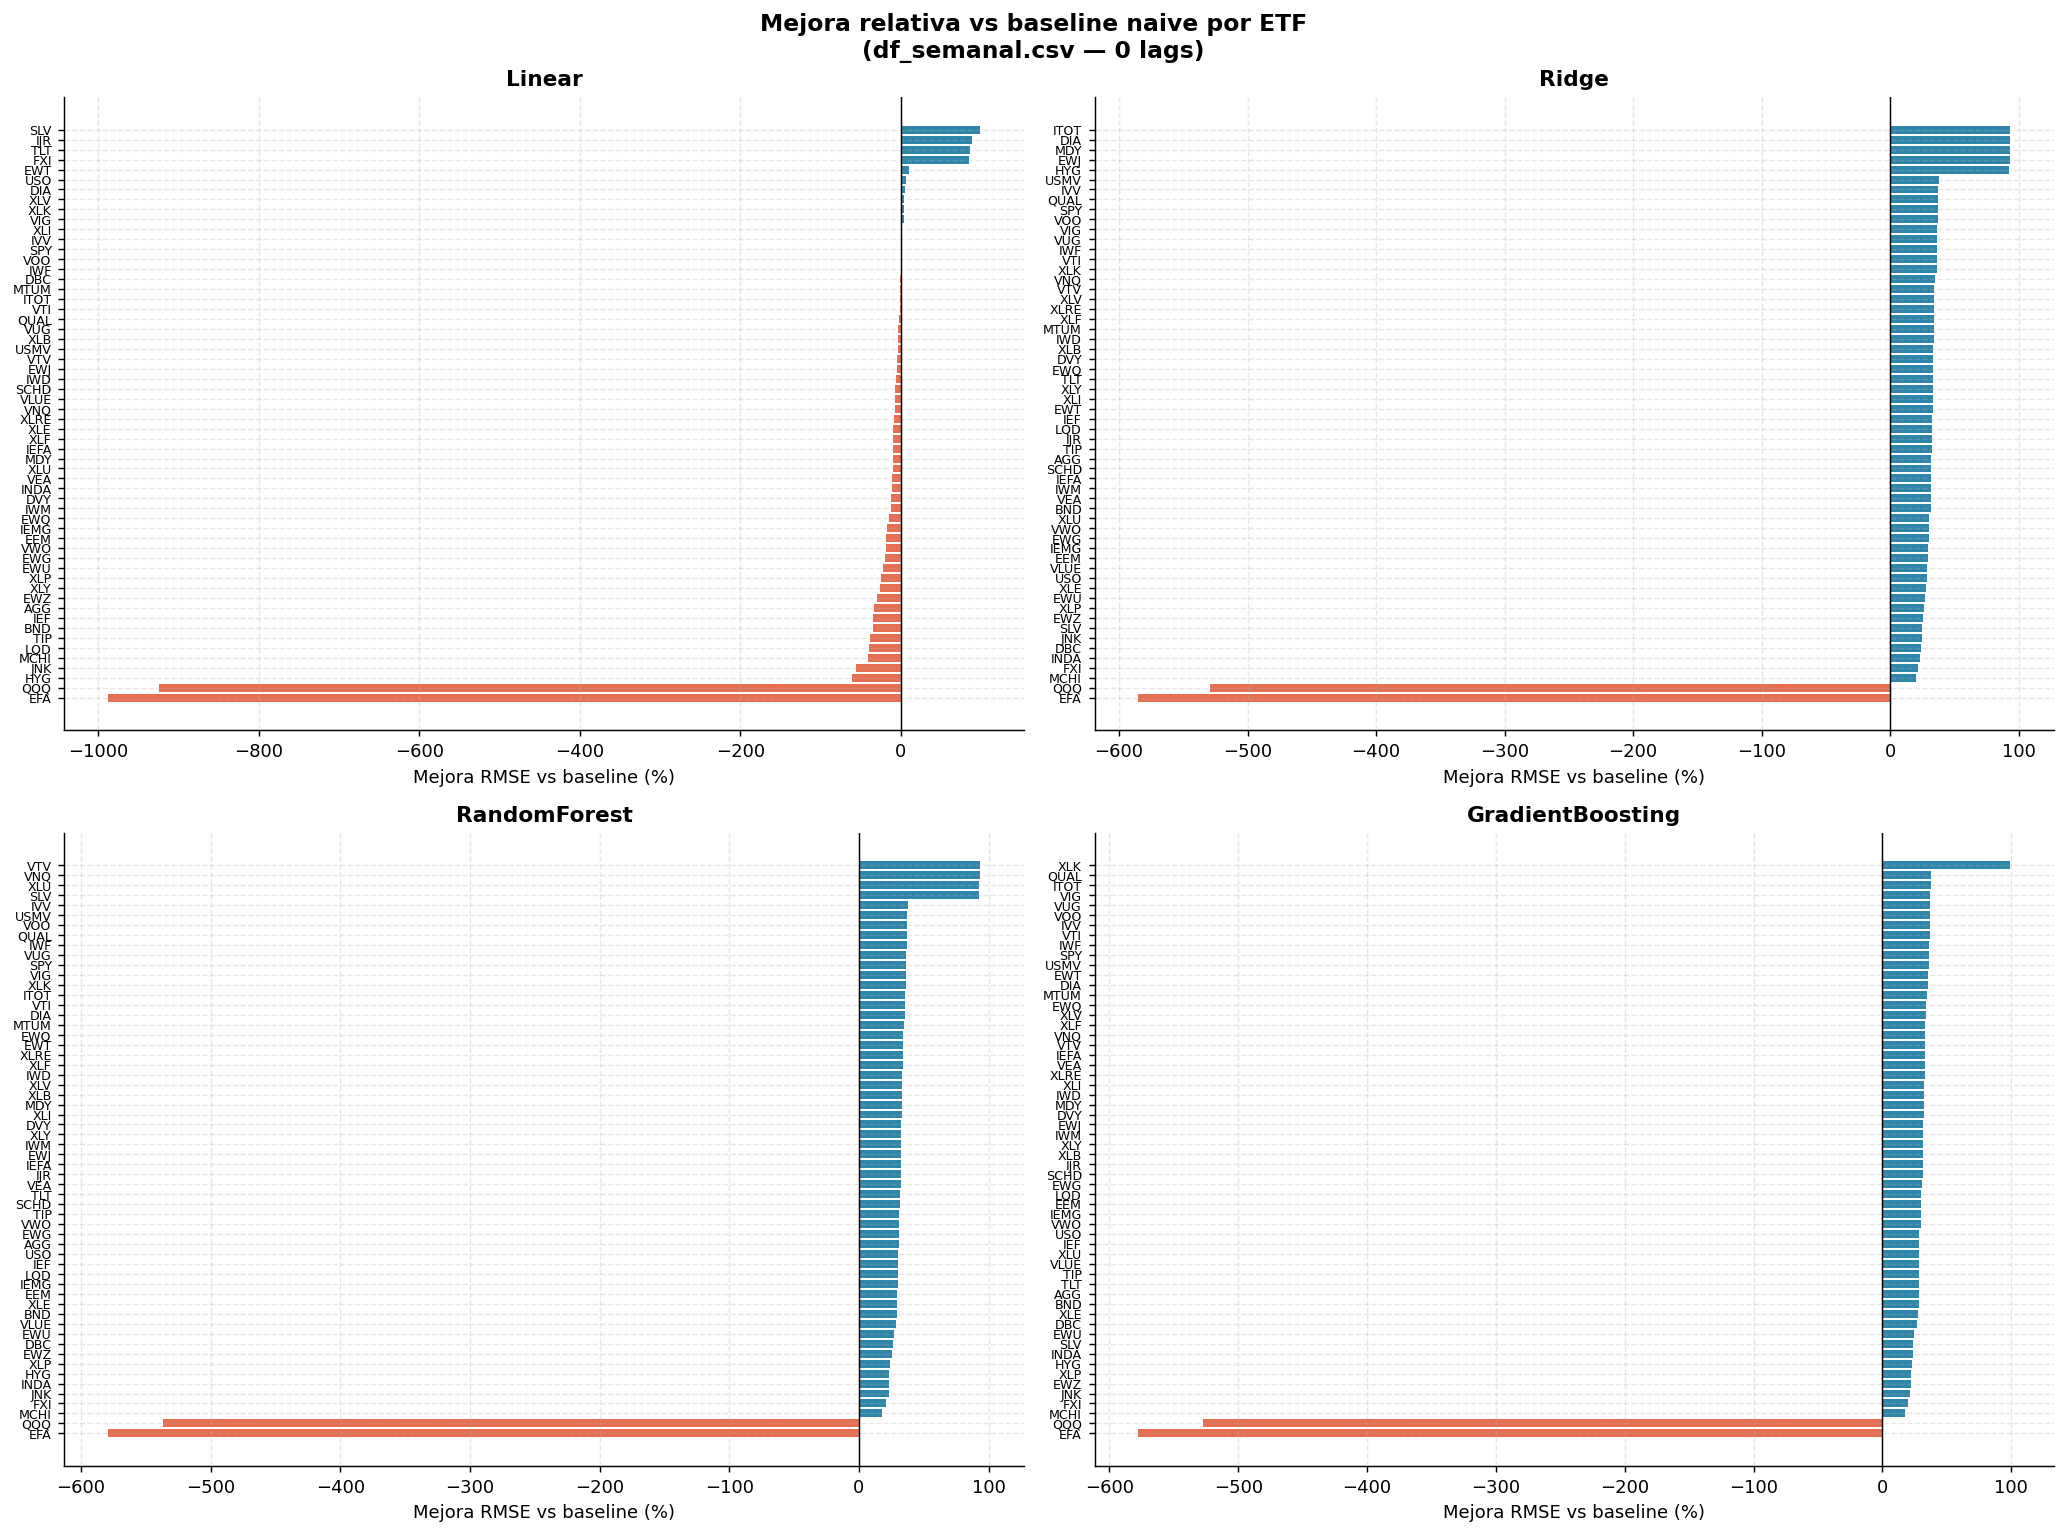

In [13]:

#  Mejora vs baseline por ETF
# Para el dataset sin lags, qué ETFs mejoran más
df0 = df[df["Archivo"] == "df_semanal.csv"].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Mejora relativa vs baseline naive por ETF\n(df_semanal.csv — 0 lags)",
             fontsize=13, fontweight="bold")

for ax, metodo in zip(axes.flatten(), metodos_lista):
    sub = df0[df0["Método"] == metodo].sort_values("Mejora_vs_baseline", ascending=True)
    colores = ["#2E86AB" if v >= 0 else "#E76F51" for v in sub["Mejora_vs_baseline"]]
    ax.barh(sub["ETF"], sub["Mejora_vs_baseline"], color=colores, edgecolor="none")
    ax.axvline(0, color="black", lw=0.8)
    ax.set_title(metodo.replace("Regressor","").replace("Regression",""), fontweight="bold")
    ax.set_xlabel("Mejora RMSE vs baseline (%)")
    ax.tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.savefig("G04_mejora_vs_baseline_por_etf.png", bbox_inches="tight")
plt.show()


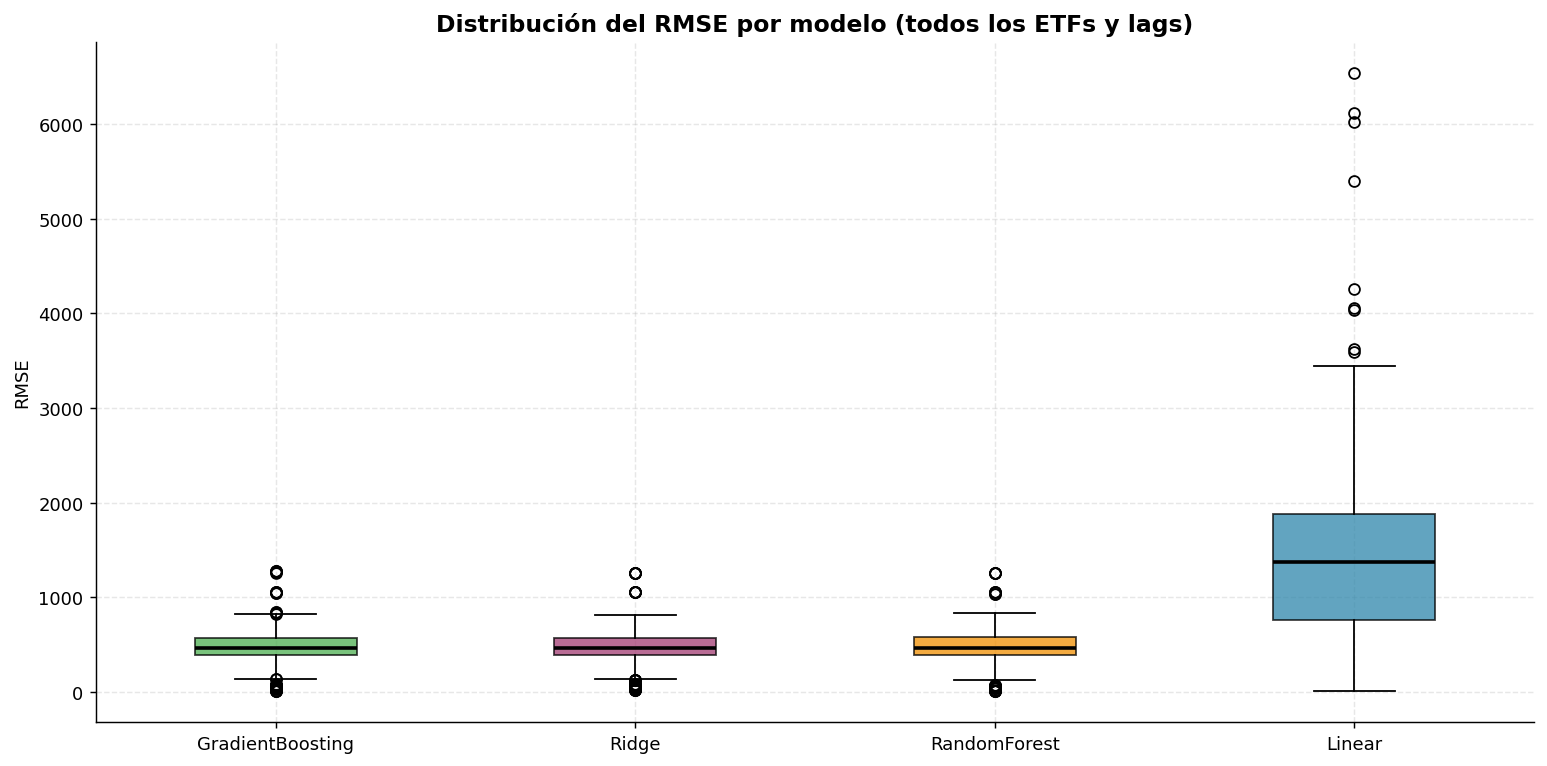

In [14]:

# Box plots RMSE por Método 
fig, ax = plt.subplots(figsize=(12, 6))
metodos_ord = df.groupby("Método")["RMSE"].median().sort_values().index.tolist()
data_box = [df[df["Método"] == m]["RMSE"].dropna().values for m in metodos_ord]
labels_box = [m.replace("Regressor","").replace("Regression","") for m in metodos_ord]
bp = ax.boxplot(data_box, labels=labels_box, patch_artist=True, notch=False,
                medianprops={"color":"black","lw":2})
for patch, m in zip(bp["boxes"], metodos_ord):
    patch.set_facecolor(COLORES_METODO.get(m, "#888"))
    patch.set_alpha(0.75)
ax.set_title("Distribución del RMSE por modelo (todos los ETFs y lags)", fontsize=13, fontweight="bold")
ax.set_ylabel("RMSE")
plt.tight_layout()
plt.savefig("G05_boxplot_rmse_por_metodo.png", bbox_inches="tight")
plt.show()


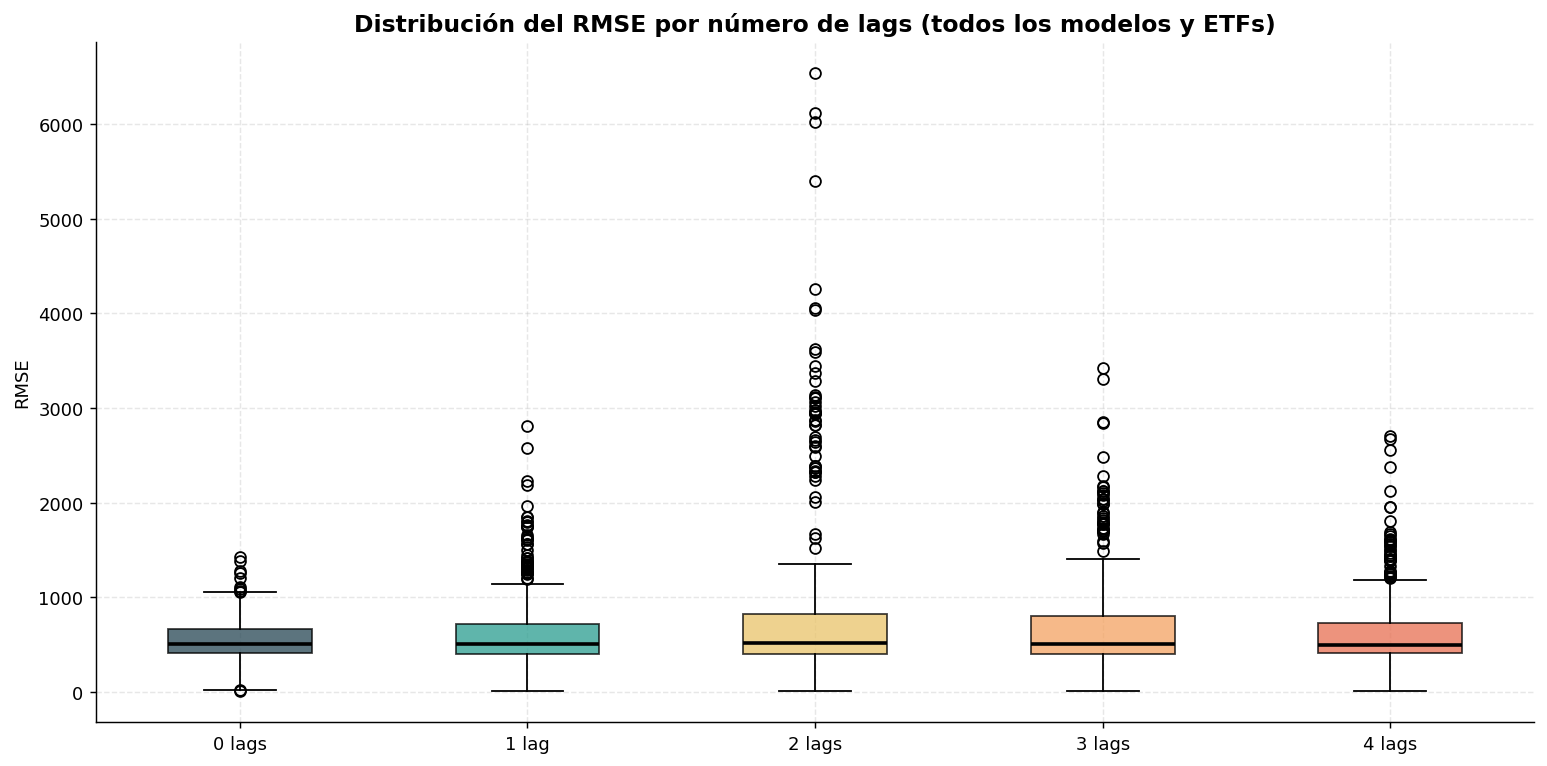

In [15]:

#  Box plots por Archivo 
fig, ax = plt.subplots(figsize=(12, 6))
archivos_ord2 = [a for a in archivos_orden if a in df["Archivo"].unique()]
data_box2 = [df[df["Archivo"] == a]["RMSE"].dropna().values for a in archivos_ord2]
labels_box2 = [LAGS_LABEL.get(a,a) for a in archivos_ord2]
bp2 = ax.boxplot(data_box2, labels=labels_box2, patch_artist=True, notch=False,
                 medianprops={"color":"black","lw":2})
for patch, a in zip(bp2["boxes"], archivos_ord2):
    patch.set_facecolor(COLORES_ARCHIVO.get(a,"#888"))
    patch.set_alpha(0.75)
ax.set_title("Distribución del RMSE por número de lags (todos los modelos y ETFs)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("RMSE")
plt.tight_layout()
plt.savefig("G06_boxplot_rmse_por_lags.png", bbox_inches="tight")
plt.show()


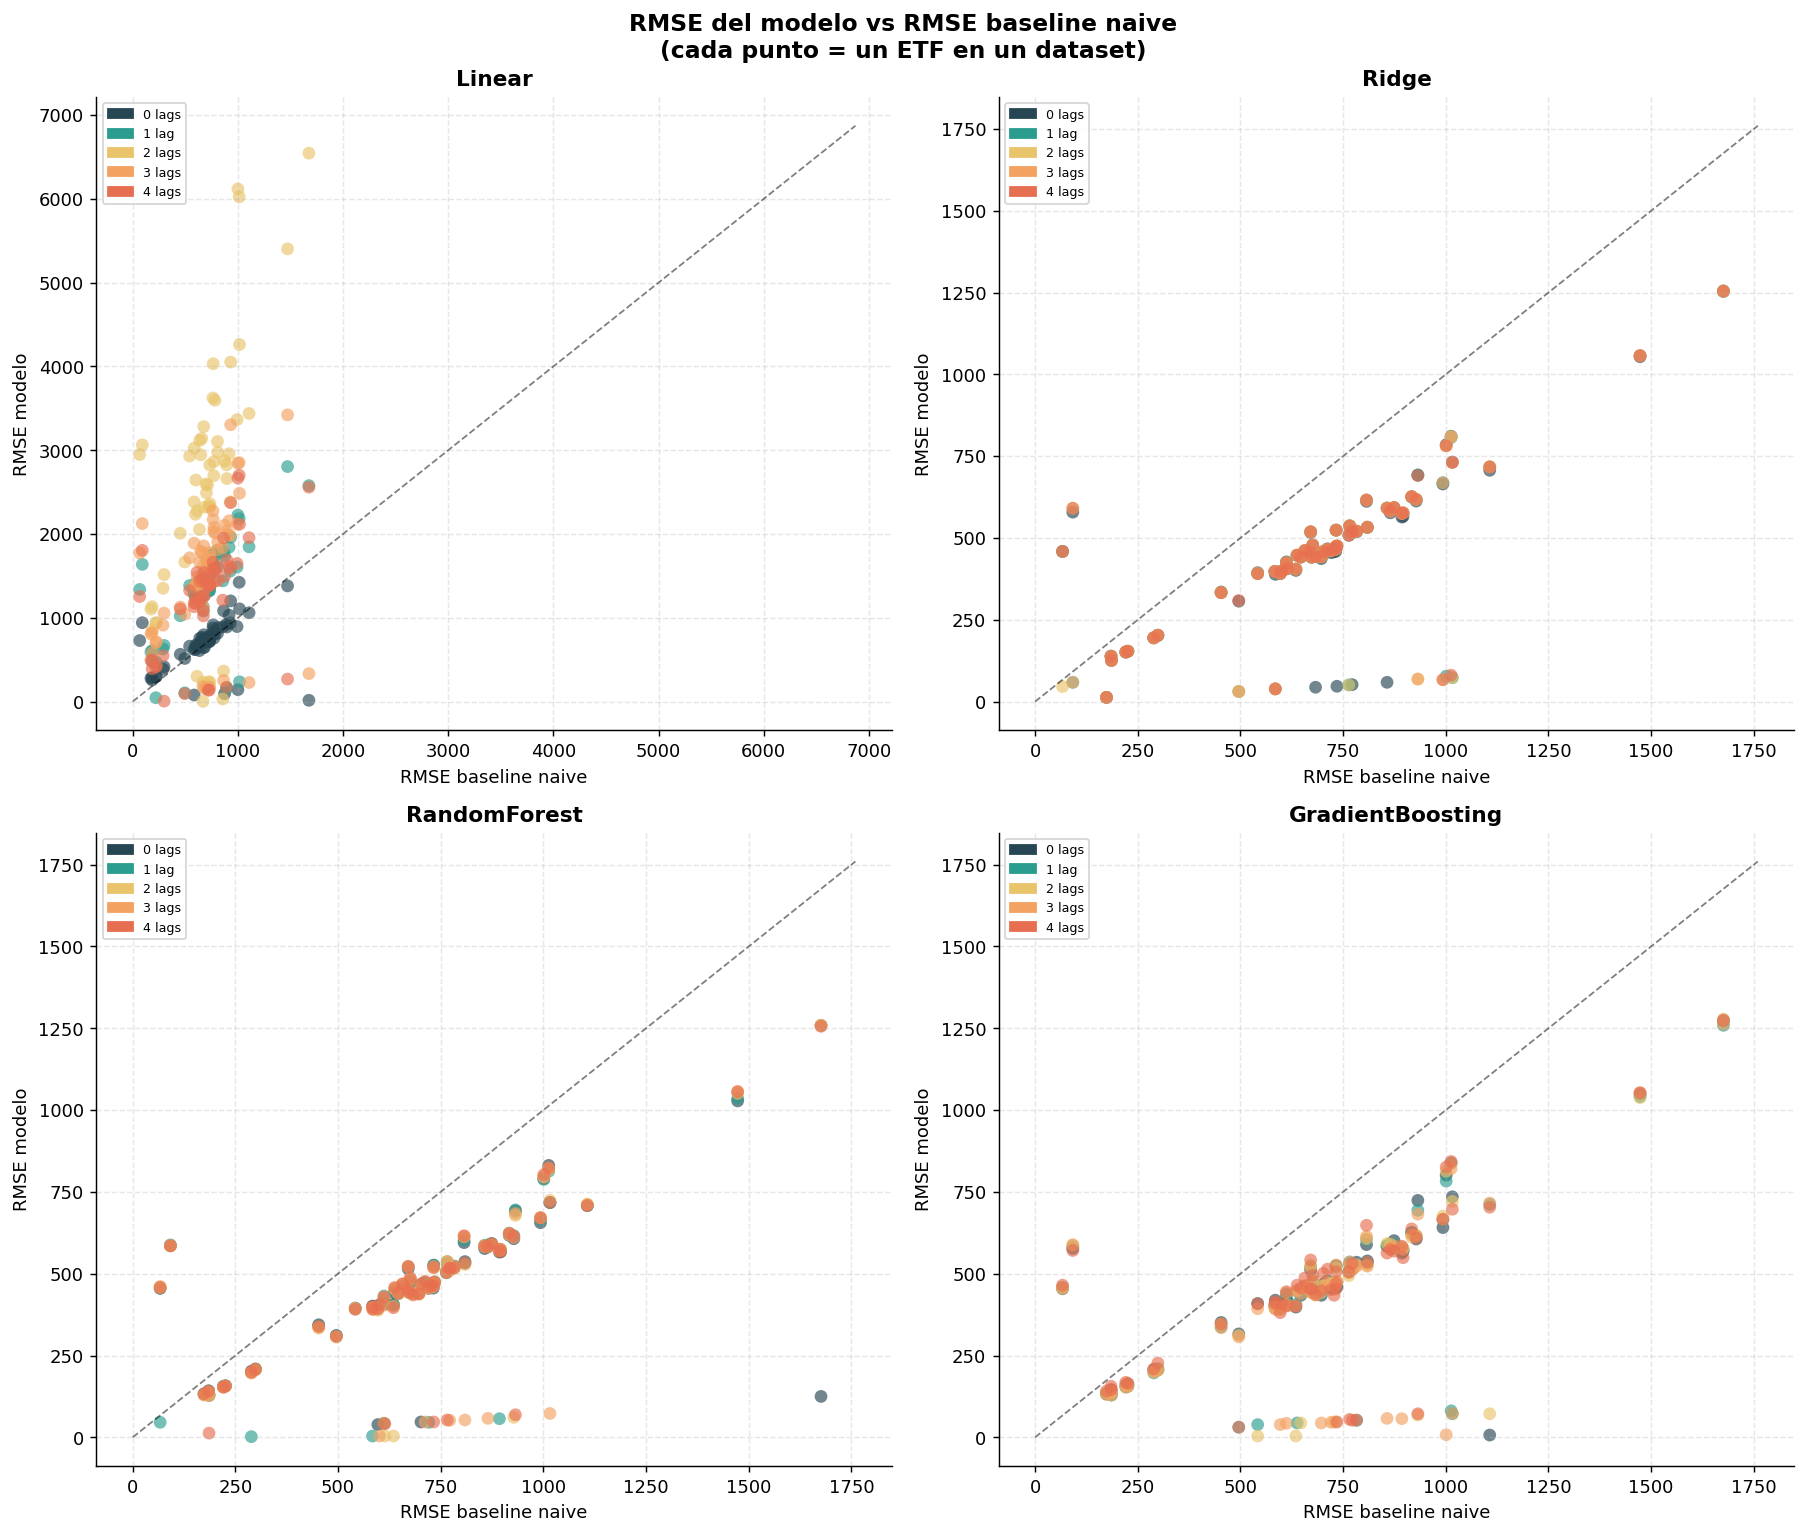

In [16]:

# Scatter RMSE modelo vs baseline 
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("RMSE del modelo vs RMSE baseline naive\n(cada punto = un ETF en un dataset)",
             fontsize=13, fontweight="bold")

for ax, metodo in zip(axes.flatten(), metodos_lista):
    sub = df[df["Método"] == metodo]
    colores_scatter = [COLORES_ARCHIVO.get(a,"#888") for a in sub["Archivo"]]
    ax.scatter(sub["RMSE_baseline"], sub["RMSE"], c=colores_scatter, alpha=0.65, s=50, edgecolors="none")
    lim = max(sub["RMSE_baseline"].max(), sub["RMSE"].max()) * 1.05
    ax.plot([0, lim], [0, lim], "k--", lw=1, alpha=0.5, label="Modelo = baseline")
    ax.set_xlabel("RMSE baseline naive")
    ax.set_ylabel("RMSE modelo")
    ax.set_title(metodo.replace("Regressor","").replace("Regression",""), fontweight="bold")

    # Leyenda de colores por archivo
    patches = [mpatches.Patch(color=COLORES_ARCHIVO.get(a,"#888"), label=LAGS_LABEL.get(a,a))
               for a in archivos_ord2]
    ax.legend(handles=patches, fontsize=7, loc="upper left")

plt.tight_layout()
plt.savefig("G07_scatter_modelo_vs_baseline.png", bbox_inches="tight")
plt.show()


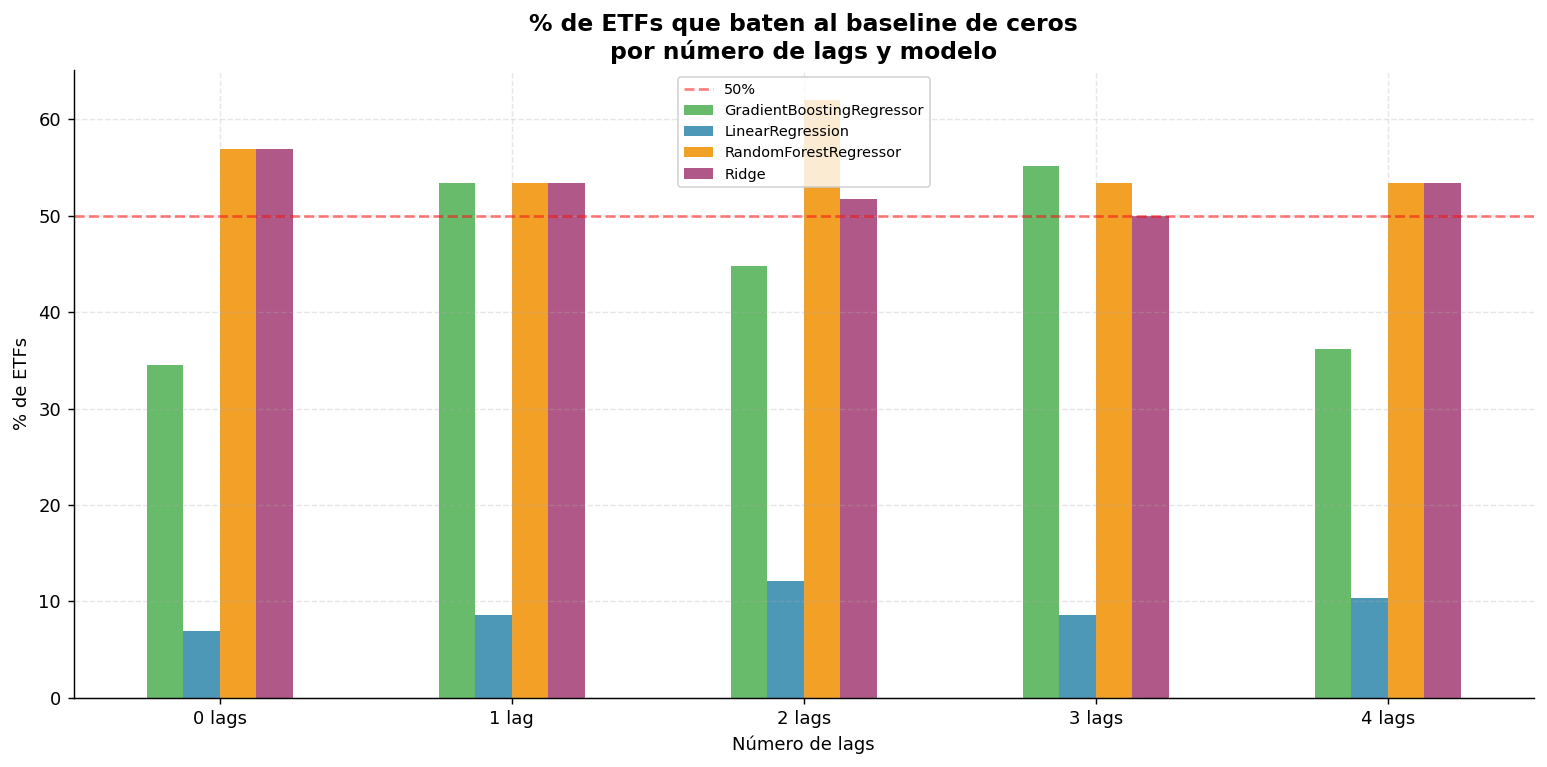

In [17]:

#  % que baten zeros por Método y Lags
pivot_zeros = df.groupby(["Lags","Método"])["Bate_zeros"].mean().unstack() * 100
pivot_zeros = pivot_zeros.reindex([l for l in ["0 lags","1 lag","2 lags","3 lags","4 lags"]
                                   if l in pivot_zeros.index])

fig, ax = plt.subplots(figsize=(12, 6))
pivot_zeros.plot(kind="bar", ax=ax,
                 color=[COLORES_METODO.get(m,"#888") for m in pivot_zeros.columns],
                 edgecolor="none", alpha=0.85)
ax.axhline(50, color="red", linestyle="--", alpha=0.5, label="50%")
ax.set_title("% de ETFs que baten al baseline de ceros\npor número de lags y modelo",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Número de lags")
ax.set_ylabel("% de ETFs")
ax.set_xticklabels(pivot_zeros.index, rotation=0)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("G08_pct_bate_zeros_lags_metodo.png", bbox_inches="tight")
plt.show()


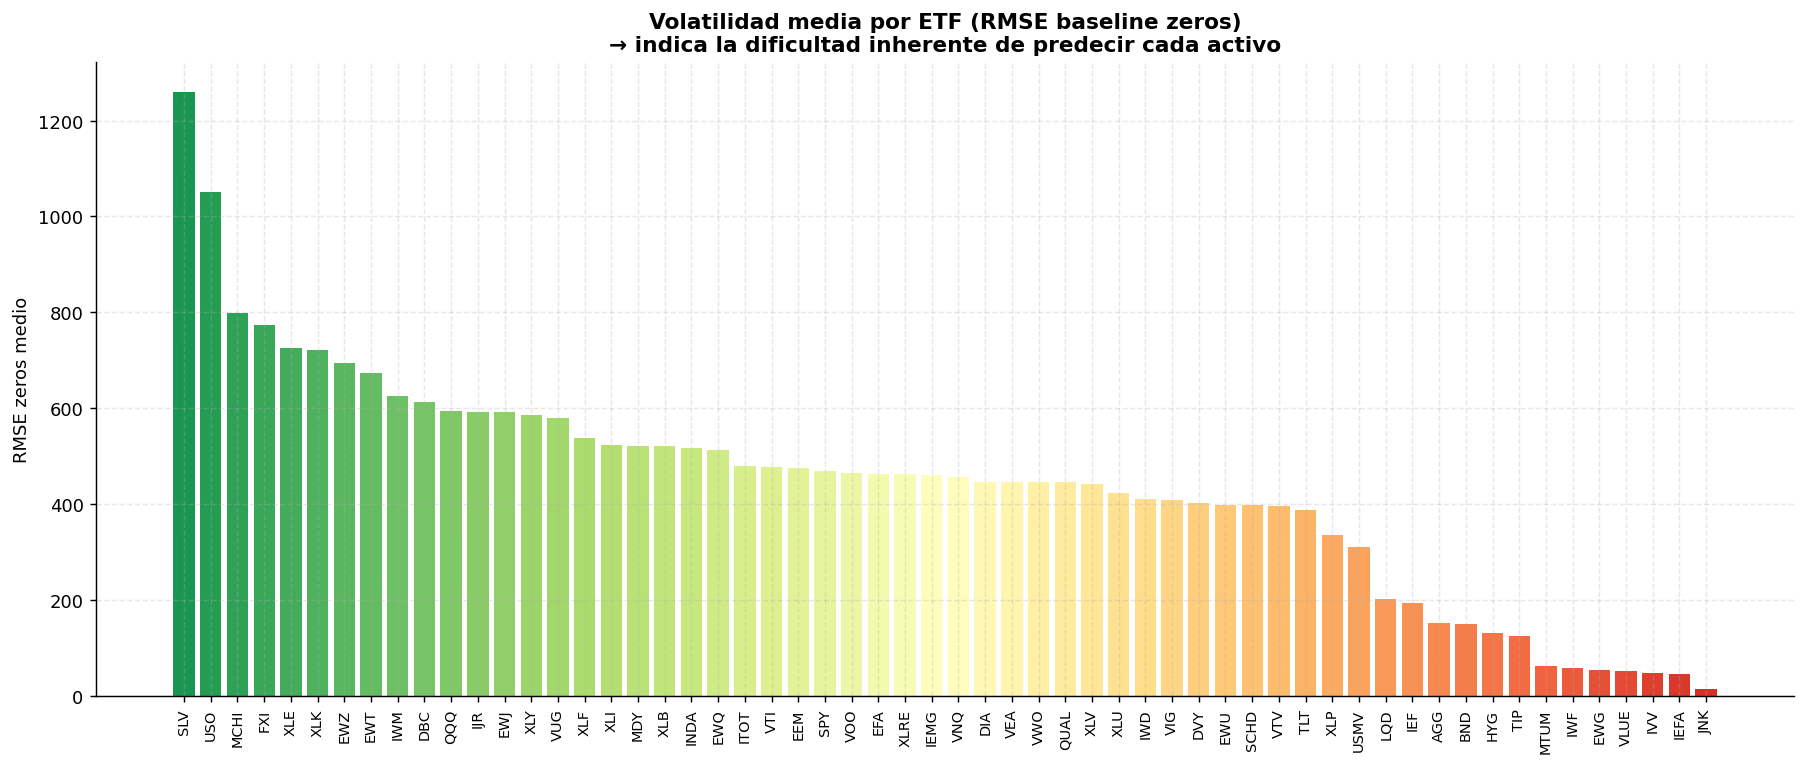

In [18]:

#  Ranking de ETFs por dificultad
# RMSE_zeros medio por ETF (cuánto ruido tiene cada activo)
dificultad = df.groupby("ETF")["RMSE_zeros"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colores_dif = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(dificultad)))
ax.bar(dificultad.index, dificultad.values, color=colores_dif, edgecolor="none")
ax.set_title("Volatilidad media por ETF (RMSE baseline zeros)\n→ indica la dificultad inherente de predecir cada activo",
             fontsize=12, fontweight="bold")
ax.set_ylabel("RMSE zeros medio")
ax.tick_params(axis="x", rotation=90, labelsize=8)
plt.tight_layout()
plt.savefig("G09_ranking_etfs_por_dificultad.png", bbox_inches="tight")
plt.show()


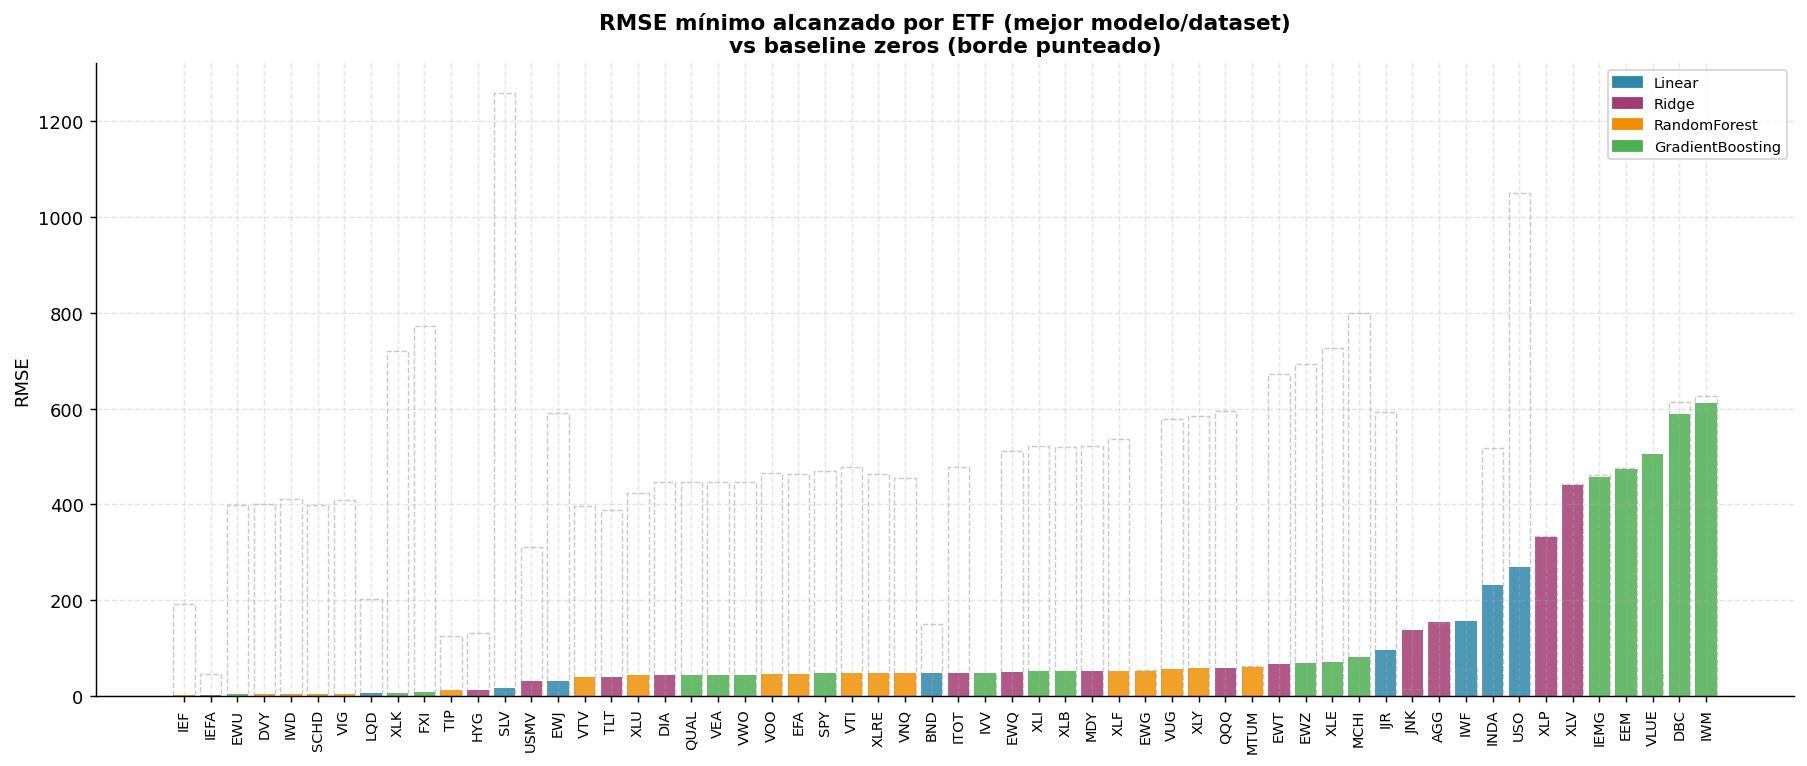

In [19]:

# RMSE por ETF del mejor modelo
# Para cada ETF, el RMSE mínimo alcanzado por cualquier modelo/dataset
mejor_etf = df.loc[df.groupby("ETF")["RMSE"].idxmin()].sort_values("RMSE")

fig, ax = plt.subplots(figsize=(14, 6))
colores_mejor = [COLORES_METODO.get(m,"#888") for m in mejor_etf["Método"]]
ax.bar(mejor_etf["ETF"], mejor_etf["RMSE"], color=colores_mejor, edgecolor="none", alpha=0.85)
ax.bar(mejor_etf["ETF"], mejor_etf["RMSE_zeros"], bottom=0, color="none",
       edgecolor="#999", lw=0.8, linestyle="--", alpha=0.5)

patches_leyenda = [mpatches.Patch(color=COLORES_METODO.get(m,"#888"), label=m.replace("Regressor","").replace("Regression",""))
                   for m in df["Método"].unique()]
ax.legend(handles=patches_leyenda, fontsize=8)
ax.set_title("RMSE mínimo alcanzado por ETF (mejor modelo/dataset)\nvs baseline zeros (borde punteado)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("RMSE")
ax.tick_params(axis="x", rotation=90, labelsize=8)
plt.tight_layout()
plt.savefig("G10_rmse_minimo_por_etf.png", bbox_inches="tight")
plt.show()



KeyboardInterrupt



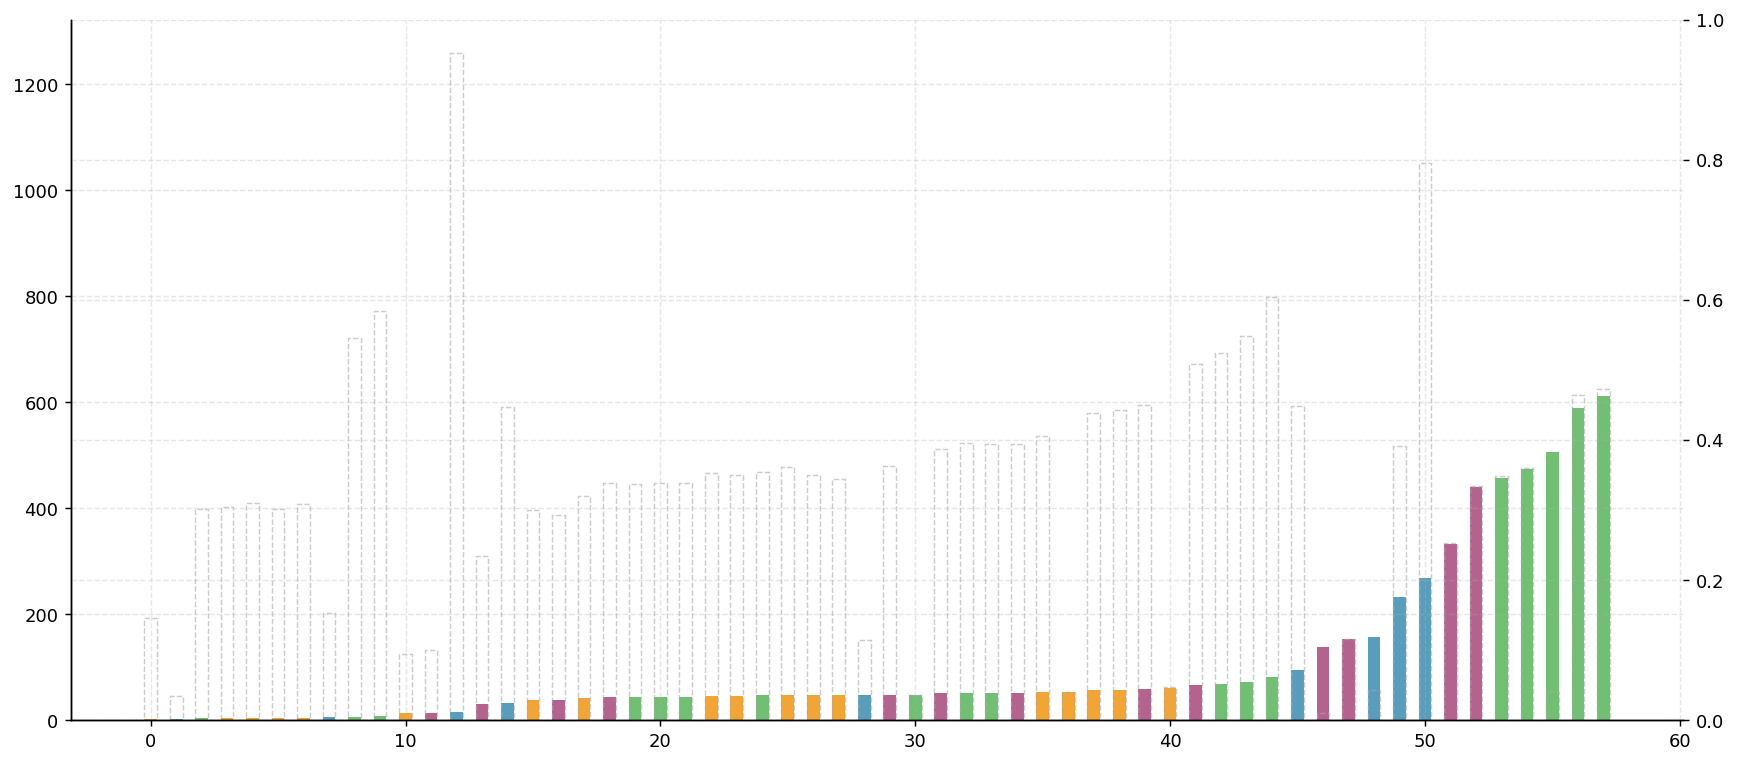

In [24]:
# G10 — RMSE mínimo por ETF + ValorReal en eje secundario
mejor_etf = df.loc[df.groupby("ETF")["RMSE"].idxmin()].sort_values("RMSE").copy()

fig, ax = plt.subplots(figsize=(16, 7))
colores_mejor = [COLORES_METODO.get(m, "#888") for m in mejor_etf["Método"]]
x = np.arange(len(mejor_etf))

# Barras de RMSE
ax.bar(x, mejor_etf["RMSE"].values, 0.5,
       color=colores_mejor, edgecolor="none", alpha=0.8, label="RMSE modelo")
ax.bar(x, mejor_etf["RMSE_zeros"].values, 0.5,
       color="none", edgecolor="#AAAAAA", lw=0.8, linestyle="--",
       alpha=0.6, label="RMSE zeros (ref)")

# ValorReal como línea en eje derecho
ax2 = ax.twinx()
vr  = mejor_etf["ValorReal"].fillna(0).values
ax2.plot(x, vr, "D-", color="#E76F51", ms=6, lw=1.5, alpha=0.9,
         label="ValorReal (retorno real acumulado test)")
ax2.axhline(0, color="#E76F51", lw=0.5, linestyle=":")
ax2.set_ylabel("Retorno real acumulado (ValorReal)", color="#E76F51", fontsize=9)
ax2.tick_params(axis="y", labelcolor="#E76F51")

# Eje X
ax.set_xticks(x)
ax.set_xticklabels(mejor_etf["ETF"].values, rotation=90, fontsize=8)
ax.set_ylabel("RMSE")
ax.set_title(
    "RMSE mínimo alcanzado por ETF vs retorno real acumulado del período de test\n"
    "— ETFs con mayor retorno real tienden a tener mayor error de predicción",
    fontsize=11, fontweight="bold"
)

# Leyenda combinada
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
patches_m = [mpatches.Patch(
    color=COLORES_METODO.get(m, "#888"),
    label=m.replace("Regressor", "").replace("Regression", ""))
    for m in df["Método"].unique()]
ax.legend(handles=h1 + h2 + patches_m, fontsize=7, loc="upper left")

plt.tight_layout()
plt.savefig("G10_rmse_minimo_con_valorreal.png", bbox_inches="tight")
plt.show()

In [ ]:
# G_VR — ValorReal por ETF: contexto del período de test
vr_etf = (
    df[df["Archivo"] == "df_semanal.csv"]
    .groupby("ETF")["ValorReal"]
    .mean()
    .dropna()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(14, 6))
colores_vr = ["#2E86AB" if v >= 0 else "#E76F51" for v in vr_etf.values]
bars = ax.barh(vr_etf.index, vr_etf.values,
               color=colores_vr, edgecolor="none", alpha=0.85)
ax.axvline(0, color="black", lw=0.8)

# Etiquetar barras
for bar, v in zip(bars, vr_etf.values):
    ax.text(v + (0.0001 if v >= 0 else -0.0001),
            bar.get_y() + bar.get_height() / 2,
            f"{v:.4f}", va="center", ha="left" if v >= 0 else "right", fontsize=7)

ax.set_xlabel("Retorno real acumulado (ValorReal)")
ax.set_title(
    "Retorno real acumulado por ETF durante el período de test\n"
    "(azul = subida, rojo = bajada) — df_semanal.csv",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig("G_VR_valorreal_por_etf.png", bbox_inches="tight")
plt.show()

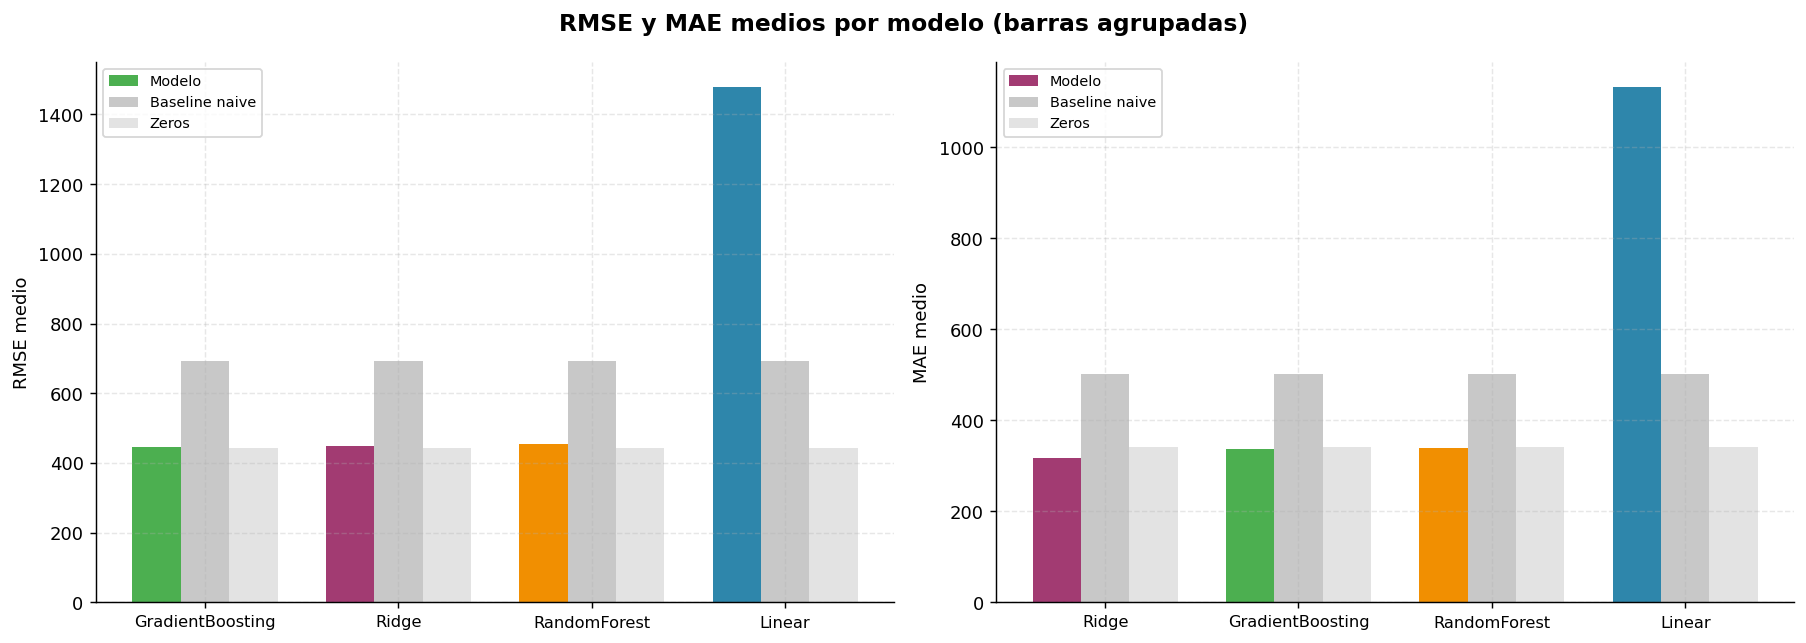

In [20]:

#  Comparativa RMSE/MAE por método 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("RMSE y MAE medios por modelo (barras agrupadas)", fontsize=13, fontweight="bold")

for ax, metric, ylabel in zip(axes, ["RMSE","MAE"], ["RMSE medio","MAE medio"]):
    base_col = f"{metric}_baseline"
    zeros_col = f"{metric}_zeros"
    medias_m = df.groupby("Método")[[metric, base_col, zeros_col]].mean().sort_values(metric)
    x = np.arange(len(medias_m))
    w = 0.25
    ax.bar(x - w, medias_m[metric],     w, color=[COLORES_METODO.get(m,"#888") for m in medias_m.index], label="Modelo")
    ax.bar(x,     medias_m[base_col],   w, color="#BBBBBB", alpha=0.8, label="Baseline naive")
    ax.bar(x + w, medias_m[zeros_col],  w, color="#DDDDDD", alpha=0.8, label="Zeros")
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace("Regressor","").replace("Regression","") for m in medias_m.index], fontsize=9)
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("G11_rmse_mae_comparativa.png", bbox_inches="tight")
plt.show()


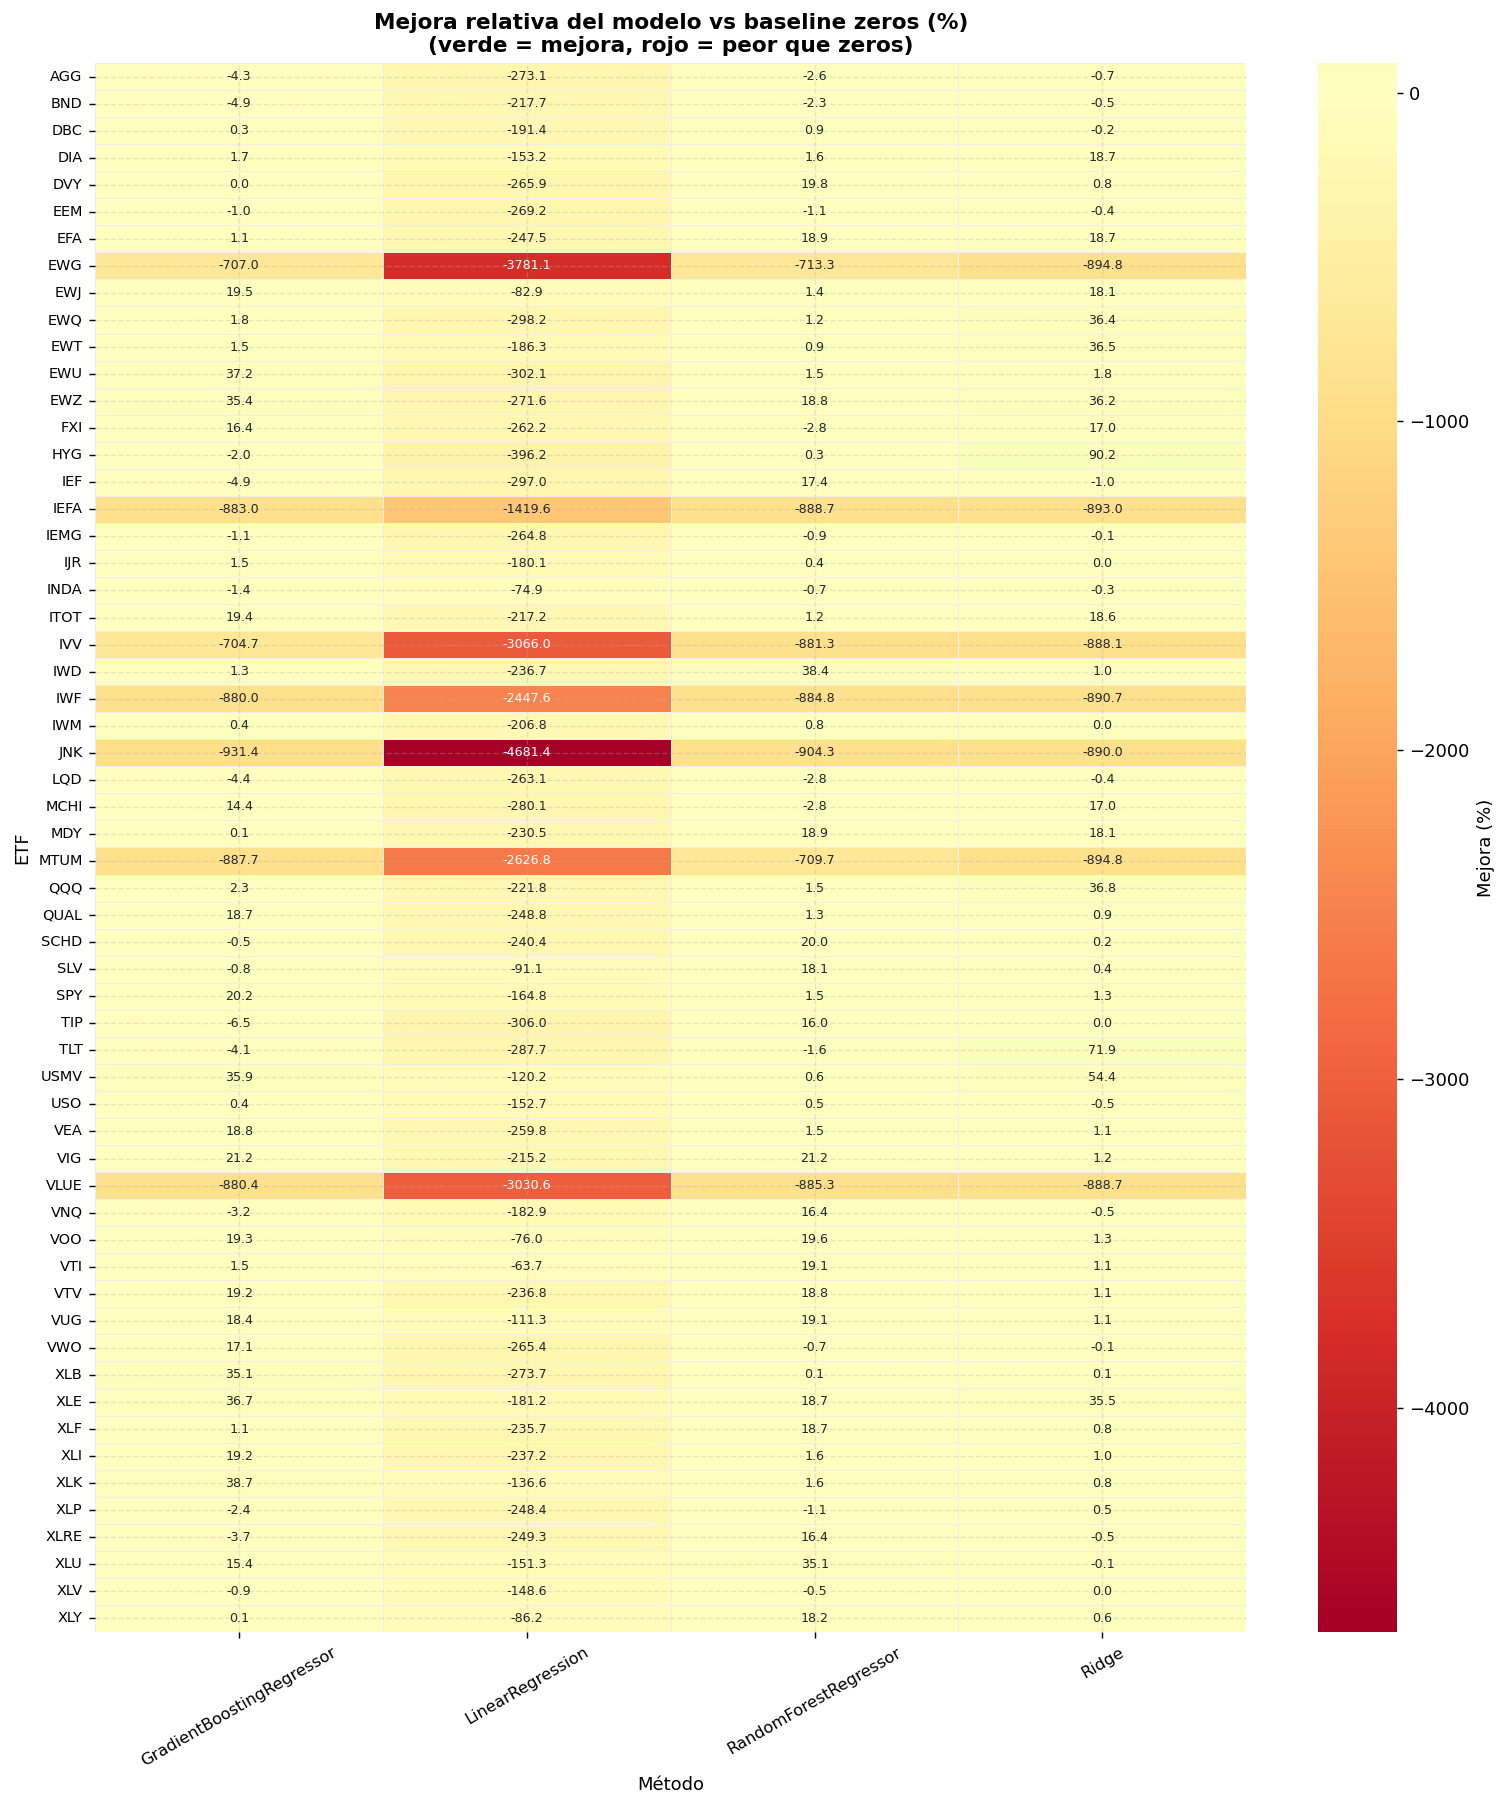

In [21]:

#  Mejora vs zeros heatmap 
pivot_mejora = df.pivot_table(
    index="ETF", columns="Método", values="Mejora_vs_zeros", aggfunc="mean"
)
fig, ax = plt.subplots(figsize=(12, 14))
sns.heatmap(
    pivot_mejora, ax=ax, cmap="RdYlGn", center=0,
    annot=True, fmt=".1f", annot_kws={"size":7},
    linewidths=0.3, linecolor="#eee", cbar_kws={"label":"Mejora (%)"}
)
ax.set_title("Mejora relativa del modelo vs baseline zeros (%)\n(verde = mejora, rojo = peor que zeros)",
             fontsize=12, fontweight="bold")
ax.tick_params(axis="x", rotation=30, labelsize=9)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.savefig("G12_heatmap_mejora_vs_zeros.png", bbox_inches="tight")
plt.show()


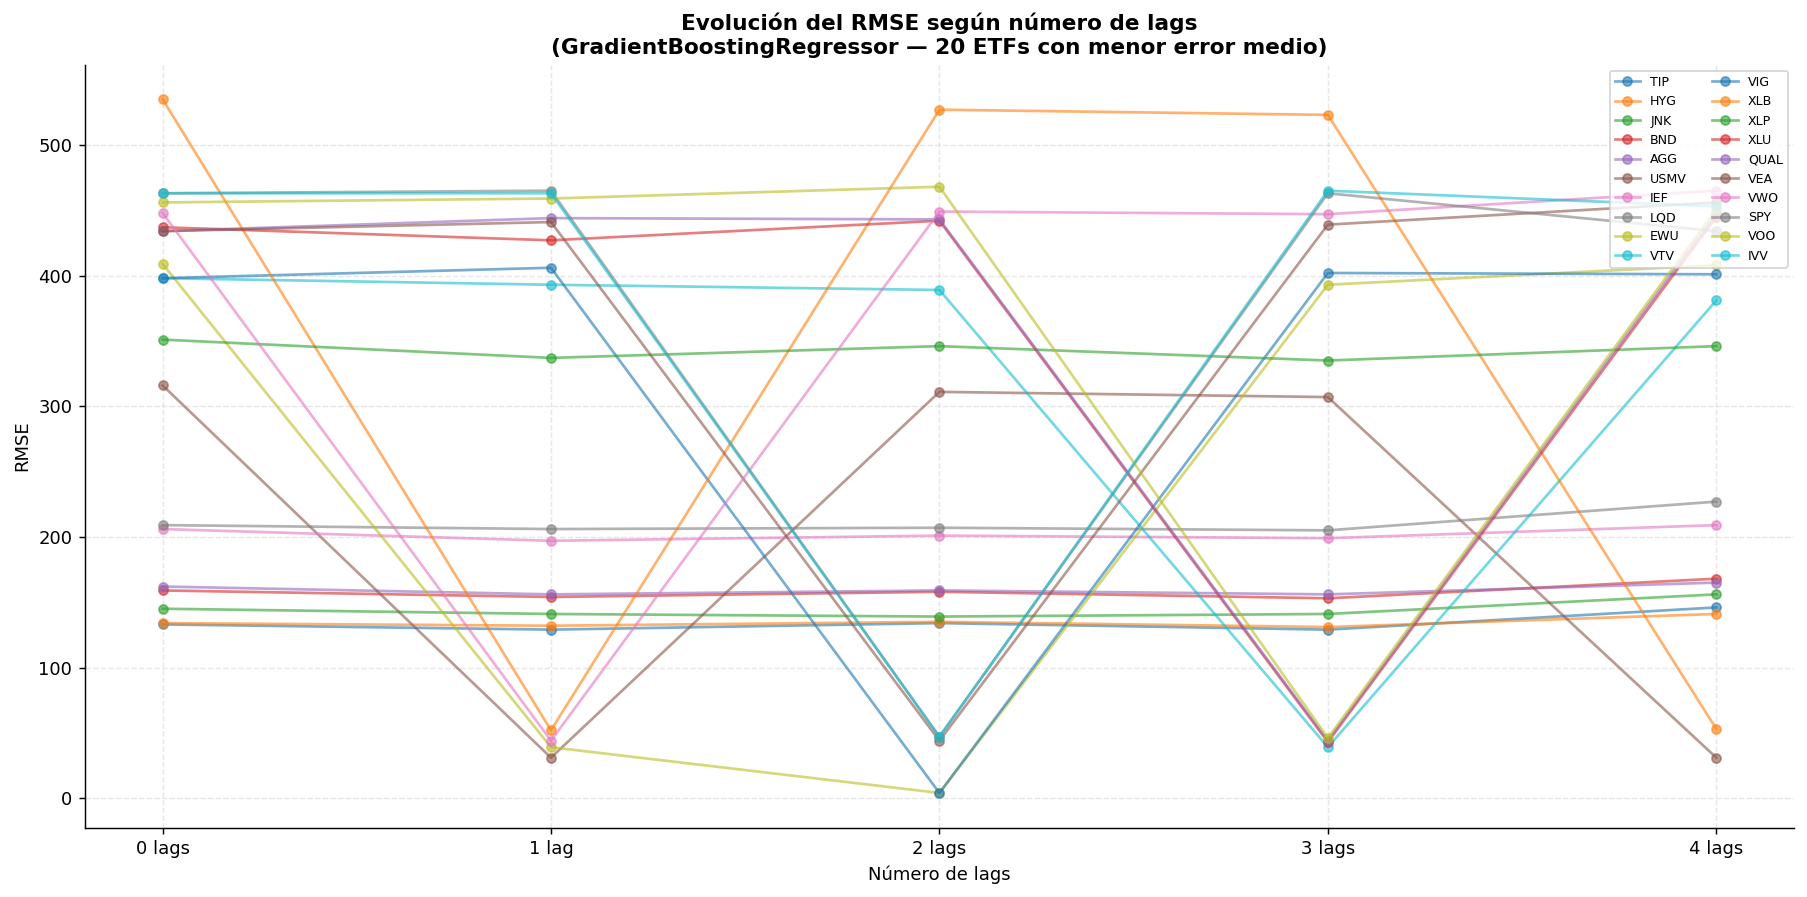

In [22]:

# GRÁFICA 13 — Líneas de RMSE a lo largo de lags
# Por ETF, cómo evoluciona el RMSE según aumentan los lags
# (solo para un método a la vez — aquí el mejor global)
mejor_metodo_global = df.groupby("Método")["RMSE"].mean().idxmin()
df_mejor = df[df["Método"] == mejor_metodo_global]

fig, ax = plt.subplots(figsize=(14, 7))
etfs_muestra = df_mejor.groupby("ETF")["RMSE"].mean().sort_values().head(20).index

for etf in etfs_muestra:
    sub = df_mejor[df_mejor["ETF"] == etf].copy()
    sub = sub.set_index("Archivo").reindex(archivos_ord2)
    ax.plot(
        [LAGS_LABEL.get(a,a) for a in archivos_ord2],
        sub["RMSE"].values,
        "o-", alpha=0.6, lw=1.5, ms=5, label=etf
    )

ax.set_title(f"Evolución del RMSE según número de lags\n({mejor_metodo_global} — 20 ETFs con menor error medio)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Número de lags")
ax.set_ylabel("RMSE")
ax.legend(fontsize=7, ncol=2, loc="upper right")
plt.tight_layout()
plt.savefig("G13_evolucion_rmse_por_lags.png", bbox_inches="tight")
plt.show()


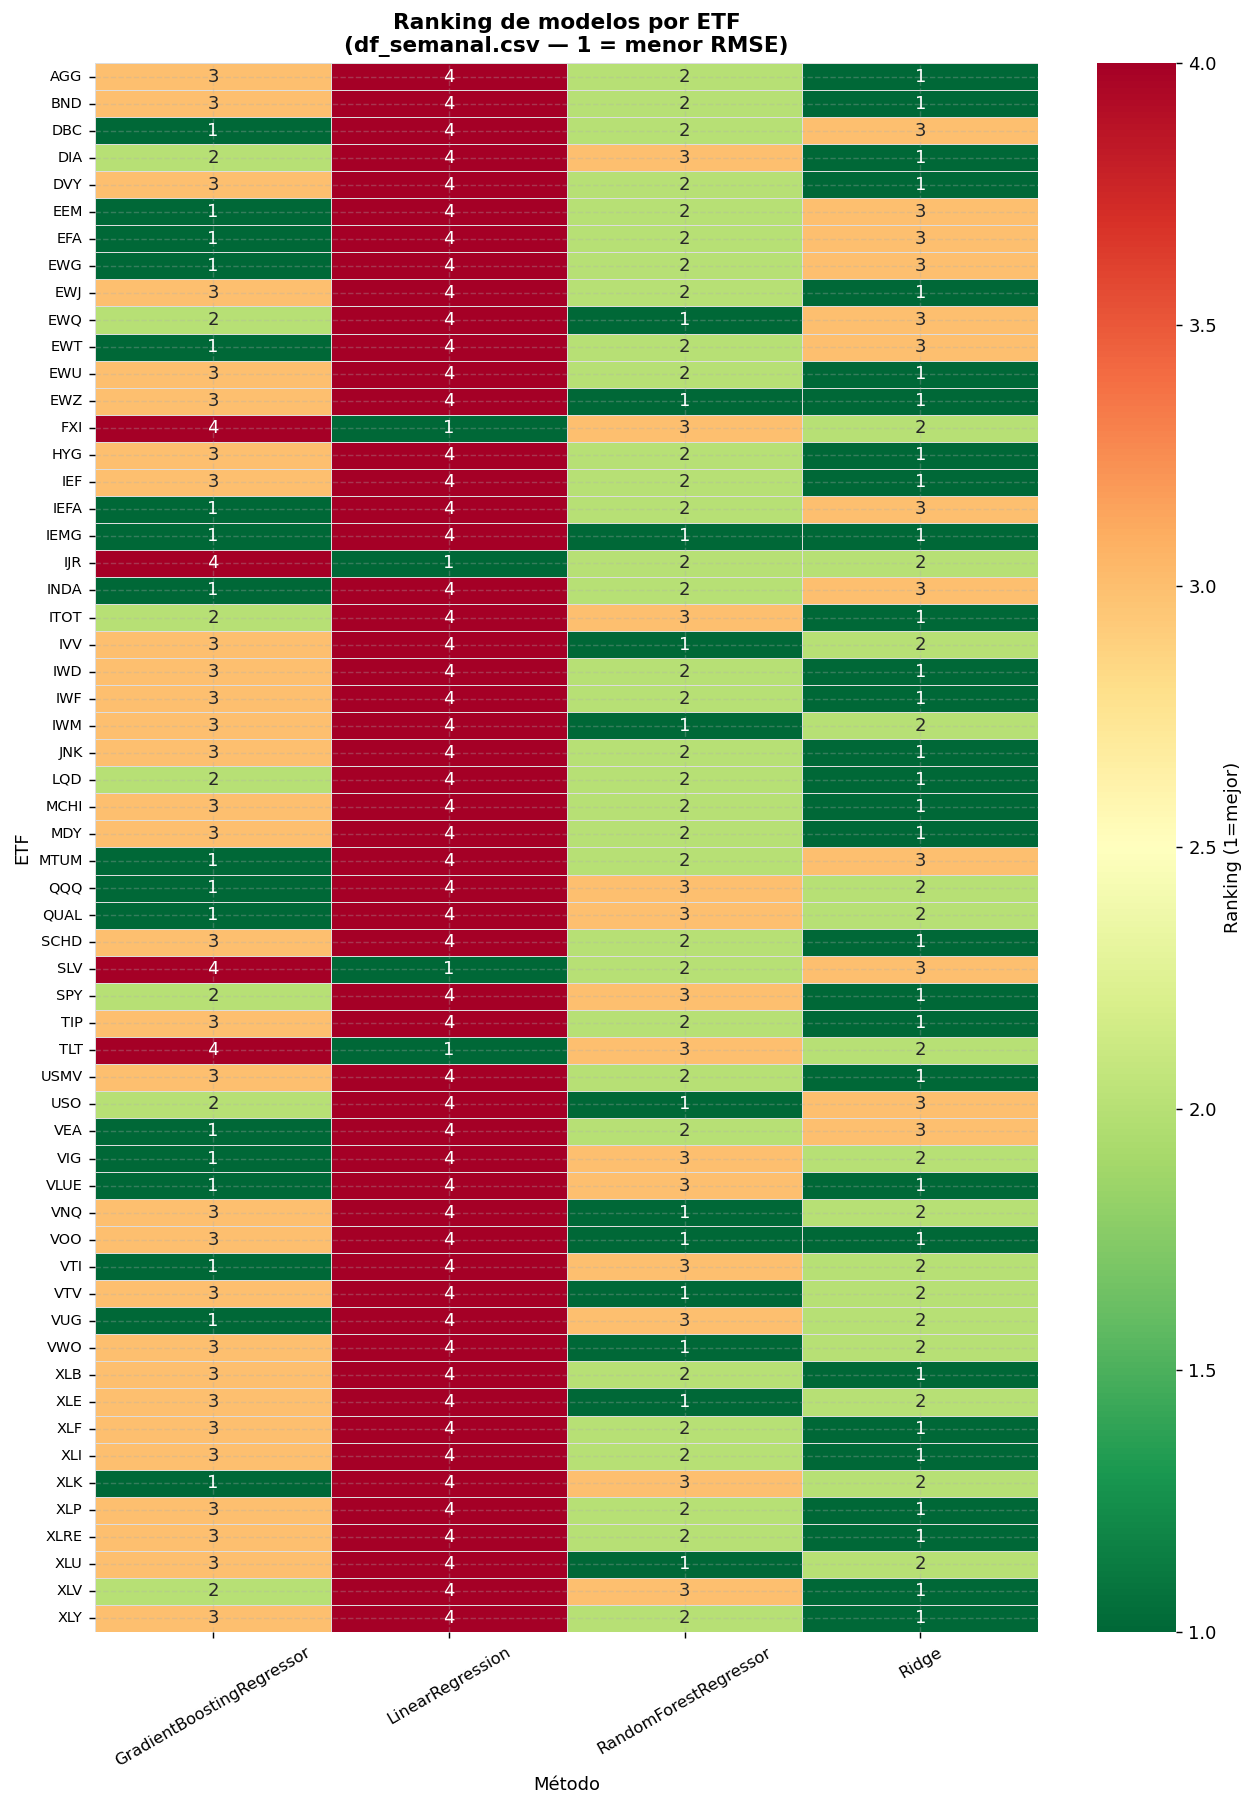


TABLA RESUMEN FINAL — Para incluir en el TFM
                                            RMSE_medio  RMSE_baseline_medio  RMSE_zeros_medio   MAE_medio  Mejora_baseline_pct  Mejora_zeros_pct  Pct_bate_baseline  Pct_bate_zeros   N
Método                    Archivo                                                                                                                                                      
GradientBoostingRegressor df_semanal.csv     481.98276            692.75862         441.67241   357.62069             11.83103        -106.19448               96.6            34.5  58
                          df_semanal_1.csv   441.77586            692.75862         441.67241   343.24138             17.63724         -98.03931               96.6            53.4  58
                          df_semanal_2.csv   436.62069            692.75862         441.67241   320.62069             18.27121         -82.49983               96.6            44.8  58
                          df_seman

In [ ]:

# Tabla visual (heatmap) ranking 
# Ranking de modelos por ETF en el dataset sin lags
df0 = df[df["Archivo"] == "df_semanal.csv"].copy()
pivot_rank = df0.pivot_table(index="ETF", columns="Método", values="RMSE", aggfunc="mean")
# Convertir a rankings (1 = mejor)
pivot_rank_num = pivot_rank.rank(axis=1, method="min").astype(int)

fig, ax = plt.subplots(figsize=(10, 14))
sns.heatmap(
    pivot_rank_num, ax=ax, cmap="RdYlGn_r", annot=True, fmt="d",
    linewidths=0.4, linecolor="#ddd",
    cbar_kws={"label":"Ranking (1=mejor)"}
)
ax.set_title("Ranking de modelos por ETF\n(df_semanal.csv — 1 = menor RMSE)",
             fontsize=12, fontweight="bold")
ax.tick_params(axis="x", rotation=30, labelsize=9)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.savefig("G14_ranking_modelos_por_etf.png", bbox_inches="tight")
plt.show()

# ── CELDA 23: TABLA FINAL EXPORTABLE ────────────────────────
print("\n" + "="*70)
print("TABLA RESUMEN FINAL — Para incluir en el TFM")
print("="*70)

tabla_final = df.groupby(["Método","Archivo"]).agg(
    RMSE_medio=("RMSE","mean"),
    RMSE_baseline_medio=("RMSE_baseline","mean"),
    RMSE_zeros_medio=("RMSE_zeros","mean"),
    MAE_medio=("MAE","mean"),
    Mejora_baseline_pct=("Mejora_vs_baseline","mean"),
    Mejora_zeros_pct=("Mejora_vs_zeros","mean"),
    Pct_bate_baseline=("Bate_baseline", lambda x: round(x.mean()*100,1)),
    Pct_bate_zeros=("Bate_zeros",    lambda x: round(x.mean()*100,1)),
    N=("RMSE","count")
).round(5)

tabla_final.to_csv("tabla_resumen_final.csv", encoding="utf-8-sig")
print(tabla_final.to_string())
print("\n Guardada en: tabla_resumen_final.csv")
print("\nGráficas guardadas: G01 a G14")

In [ ]:
# ═══════════════════════════════════════════════════════════════
# BLOQUE D — KAPPA DE COHEN Y ACCURACY DIRECCIONAL
# (requiere los CSV guardados por el runner en carpeta predicciones/)
# ═══════════════════════════════════════════════════════════════
from sklearn.metrics import cohen_kappa_score, accuracy_score

# ── Cargar CSVs de predicciones ──────────────────────────────
archivos_pred = glob.glob("predicciones/pred_*.csv")

lista_pred = []
for f in archivos_pred:
    try:
        lista_pred.append(pd.read_csv(f))
    except Exception as e:
        print(f"Error: {f} → {e}")

if not lista_pred:
    print("⚠️  No se encontraron CSVs en carpeta 'predicciones/'.")
    print("   Asegúrate de haber ejecutado el runner con el código de guardado.")
else:
    df_pred = pd.concat(lista_pred, ignore_index=True)
    print(f"Predicciones cargadas: {len(df_pred)} filas")

# ── Calcular Kappa y Accuracy ─────────────────────────────────
def calcular_direccional(df_pred):
    filas = []
    for (etf, metodo, archivo), g in df_pred.groupby(["ETF","Método","Archivo"]):
        g = g.dropna(subset=["real","pred_model","pred_baseline"])
        if len(g) < 5:
            continue

        real_dir = (g["real"]          > 0).astype(int)
        pred_dir = (g["pred_model"]    > 0).astype(int)
        base_dir = (g["pred_baseline"] > 0).astype(int)

        try:
            kappa_m = round(cohen_kappa_score(real_dir, pred_dir), 4)
        except Exception:
            kappa_m = np.nan
        try:
            kappa_b = round(cohen_kappa_score(real_dir, base_dir), 4)
        except Exception:
            kappa_b = np.nan

        acc_m = round(accuracy_score(real_dir, pred_dir) * 100, 1)
        acc_b = round(accuracy_score(real_dir, base_dir) * 100, 1)

        filas.append({
            "ETF":               etf,
            "Método":            metodo,
            "Archivo":           archivo,
            "Lags":              LAGS_LABEL.get(archivo, archivo),
            "Accuracy_modelo":   acc_m,
            "Accuracy_baseline": acc_b,
            "Kappa_modelo":      kappa_m,
            "Kappa_baseline":    kappa_b,
            "N":                 len(g),
        })
    return pd.DataFrame(filas)

df_dir = calcular_direccional(df_pred)

# ── T6 — Kappa y Accuracy por Método ─────────────────────────
print("\n" + "="*65)
print("T6 — Kappa de Cohen y Accuracy por Método (media ETFs y lags)")
print("="*65)
t6 = (df_dir.groupby("Método")[
    ["Accuracy_modelo","Accuracy_baseline","Kappa_modelo","Kappa_baseline"]]
    .mean().round(3)
    .sort_values("Kappa_modelo", ascending=False))
print(t6.to_string())

# ── T7 — Kappa por ETF y Método ──────────────────────────────
print("\n" + "="*65)
print("T7 — Kappa por ETF y Método (media de lags)")
print("="*65)
t7 = (df_dir.groupby(["ETF","Método"])["Kappa_modelo"]
      .mean().unstack("Método").round(3))
t7["Mejor"] = t7.max(axis=1)
print(t7.sort_values("Mejor", ascending=False).to_string())

# ── G_K1 — Kappa por Método y Lags ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Kappa de Cohen — calidad del acierto direccional\n"
    "(0 = azar puro  |  >0.2 = acuerdo justo  |  negativo = peor que azar)",
    fontsize=12, fontweight="bold"
)

# Por método
ax = axes[0]
kappa_m = df_dir.groupby("Método")["Kappa_modelo"].mean().sort_values(ascending=False)
bars = ax.bar(
    [m.replace("Regressor","").replace("Regression","") for m in kappa_m.index],
    kappa_m.values,
    color=[COLORES_METODO.get(m,"#888") for m in kappa_m.index],
    edgecolor="none", alpha=0.85
)
ax.axhline(0,   color="black", lw=1)
ax.axhline(0.2, color="green", lw=1, linestyle="--", alpha=0.6, label="Acuerdo justo (0.2)")
ax.set_ylabel("Kappa medio"); ax.set_title("Por modelo"); ax.legend(fontsize=8)
for bar, v in zip(bars, kappa_m.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.003,
            f"{v:.3f}", ha="center", fontsize=9, fontweight="bold")

# Por lags
ax2 = axes[1]
kappa_l = df_dir.groupby("Archivo")["Kappa_modelo"].mean()
colores_kl = [COLORES_ARCHIVO.get(a,"#888") for a in kappa_l.index]
kappa_l.index = [LAGS_LABEL.get(a,a) for a in kappa_l.index]
bars2 = ax2.bar(kappa_l.index, kappa_l.values, color=colores_kl, edgecolor="none", alpha=0.85)
ax2.axhline(0,   color="black", lw=1)
ax2.axhline(0.2, color="green", lw=1, linestyle="--", alpha=0.6, label="Acuerdo justo (0.2)")
ax2.set_ylabel("Kappa medio"); ax2.set_title("Por número de lags"); ax2.legend(fontsize=8)
for bar, v in zip(bars2, kappa_l.values):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.003,
             f"{v:.3f}", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("G_K1_kappa_por_metodo_y_lags.png", bbox_inches="tight")
plt.show()

# ── G_K2 — Heatmap Kappa por ETF y Método ────────────────────
pivot_kappa = (df_dir.groupby(["ETF","Método"])["Kappa_modelo"]
               .mean().unstack("Método"))

fig, ax = plt.subplots(figsize=(11, 14))
sns.heatmap(
    pivot_kappa, ax=ax, cmap="RdYlGn", center=0,
    annot=True, fmt=".2f", annot_kws={"size":8},
    linewidths=0.3, linecolor="#eee",
    cbar_kws={"label":"Kappa de Cohen"}
)
ax.set_title(
    "Kappa de Cohen por ETF y Modelo\n"
    "(verde = mejor que azar  |  rojo = peor que azar)",
    fontsize=12, fontweight="bold"
)
ax.tick_params(axis="x", rotation=30, labelsize=9)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.savefig("G_K2_heatmap_kappa.png", bbox_inches="tight")
plt.show()

# ── G_K3 — Serie temporal de un ETF con ValorReal ────────────
# Cambia estos tres valores para explorar
ETF_VER     = "SPY"
METODO_VER  = "RandomForestRegressor"
ARCHIVO_VER = "df_semanal.csv"

sub_vis = df_pred[
    (df_pred["ETF"]     == ETF_VER) &
    (df_pred["Método"]  == METODO_VER) &
    (df_pred["Archivo"] == ARCHIVO_VER)
].copy()

if sub_vis.empty:
    print(f"No hay predicciones para {ETF_VER}/{METODO_VER}/{ARCHIVO_VER}")
else:
    # Recuperar ValorReal del df resumen
    vr_valor = df[
        (df["ETF"]     == ETF_VER) &
        (df["Método"]  == METODO_VER) &
        (df["Archivo"] == ARCHIVO_VER)
    ]["ValorReal"].values
    valor_real_label = f"ValorReal = {vr_valor[0]:.5f}" if len(vr_valor) else ""

    fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
    fig.suptitle(
        f"Predicción vs Real — {ETF_VER} | {METODO_VER} | {ARCHIVO_VER}\n"
        f"({valor_real_label})",
        fontsize=13, fontweight="bold"
    )
    x       = range(len(sub_vis))
    semanas = sub_vis["week_key"].values if "week_key" in sub_vis.columns else range(len(sub_vis))

    # Panel 1 — Serie de retornos + ValorReal como línea horizontal
    ax = axes[0]
    ax.plot(x, sub_vis["real"].values,          lw=2,   color="#1a1a2e",
            label="Real",     zorder=5)
    ax.plot(x, sub_vis["pred_model"].values,    lw=1.5, color=COLORES_METODO.get(METODO_VER,"#333"),
            label="Modelo",   zorder=4, alpha=0.85)
    ax.plot(x, sub_vis["pred_baseline"].values, lw=1,   color="#AAAAAA",
            linestyle="--",   label="Baseline", zorder=3, alpha=0.7)
    ax.axhline(0, color="black", lw=0.6, alpha=0.4)
    # ValorReal como referencia horizontal
    if len(vr_valor):
        ax.axhline(vr_valor[0], color="#E76F51", lw=1.2, linestyle=":",
                   label=f"ValorReal ({vr_valor[0]:.5f})", alpha=0.8)
    ax.set_ylabel("Retorno semanal")
    ax.set_title("Serie de retornos: real vs predicción (línea naranja = ValorReal resumen)")
    ax.legend(fontsize=8)

    # Panel 2 — Error por semana
    ax2 = axes[1]
    error = sub_vis["pred_model"].values - sub_vis["real"].values
    colores_err = ["#E76F51" if e > 0 else "#2E86AB" for e in error]
    ax2.bar(x, error, color=colores_err, edgecolor="none", alpha=0.8)
    ax2.axhline(0, color="black", lw=0.8)
    ax2.set_ylabel("Error (pred − real)")
    ax2.set_title("Error de predicción por semana")

    # Panel 3 — Acierto direccional con Kappa
    ax3 = axes[2]
    real_dir = (sub_vis["real"]       > 0).astype(int).values
    pred_dir = (sub_vis["pred_model"] > 0).astype(int).values
    acierto  = (real_dir == pred_dir).astype(int)
    try:
        kappa_val = cohen_kappa_score(real_dir, pred_dir)
    except Exception:
        kappa_val = float("nan")

    colores_ac = ["#2E86AB" if a == 1 else "#E76F51" for a in acierto]
    ax3.bar(x, acierto, color=colores_ac, edgecolor="none", alpha=0.8)
    ax3.axhline(0.5, color="red", lw=1, linestyle="--", alpha=0.5)
    ax3.set_yticks([0, 1])
    ax3.set_yticklabels(["Falla", "Acierta"])
    ax3.set_ylabel("Dirección")
    ax3.set_title(
        f"Acierto direccional — "
        f"Accuracy={acierto.mean()*100:.1f}%  |  "
        f"Kappa={kappa_val:.3f}"
    )

    paso = max(1, len(x)//12)
    ax3.set_xticks(list(x)[::paso])
    ax3.set_xticklabels(list(semanas)[::paso], rotation=45, fontsize=7, ha="right")

    plt.tight_layout()
    plt.savefig(f"G_K3_serie_{ETF_VER}_{METODO_VER}.png", bbox_inches="tight")
    plt.show()

# ── Guardar tabla Kappa ───────────────────────────────────────
df_dir.to_csv("tabla_kappa_accuracy.csv", index=False, encoding="utf-8-sig")
print("\n✅ tabla_kappa_accuracy.csv guardada")
print("✅ Gráficas: G10, G_VR, G_K1, G_K2, G_K3")